<a href="https://colab.research.google.com/github/Joydas2003/Electrical-Load-Forcasting-Ml/blob/master/Machine%20Learning%20Based%20short%20term%20Electrical%20Load%20Forcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')
pgcb_df=pd.read_csv( "/content/drive/MyDrive/Load Forcasting/PGCB_date_power_demand.csv")
nasa_df=pd.read_csv("/content/drive/MyDrive/Load Forcasting/Hourly_Temp_Humidity (2).csv")
from IPython.display import display

display(pgcb_df)
display(nasa_df)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks
0,4/19/2015 22:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,4/19/2015 21:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,4/19/2015 19:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN
3,4/19/2015 18:30,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak
4,4/19/2015 18:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92645,6/17/2025 4:00,12698.0,12698,0,6030,834,3610,172,0.0,42.0,924,38,1010.0,38.0,NaN
92646,6/17/2025 3:00,13280.0,13280,0,6347,999,3698,172,0.0,40.0,924,38,1024.0,38.0,NaN
92647,6/17/2025 2:00,13719.0,13719,0,6340,1196,3881,172,0.0,27.0,924,36,1105.0,38.0,NaN
92648,6/17/2025 1:00,14093.0,14115,21,6323,1350,4019,172,0.0,28.0,924,38,1201.0,38.0,NaN


,datetime,Temperature_C,Humidity_%
0,2015-01-19 00:00:00,13.79,66.79
1,2015-01-19 01:00:00,13.25,69.37
2,2015-01-19 02:00:00,12.73,72.19
3,2015-01-19 03:00:00,12.21,75.48
4,2015-01-19 04:00:00,11.78,78.84
...,...,...,...
91267,2025-06-17 19:00:00,26.98,95.39
91268,2025-06-17 20:00:00,26.81,96.40
91269,2025-06-17 21:00:00,26.70,96.67
91270,2025-06-17 22:00:00,26.61,96.64


In [3]:

pgcb_df['datetime'] = pd.to_datetime(pgcb_df['datetime'])
nasa_df['datetime'] = pd.to_datetime(nasa_df['datetime'])

df = pd.merge(pgcb_df, nasa_df, on='datetime', how='left')

# Display
from IPython.display import display
display(df)

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,26.48,84.04
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,26.92,80.84
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN,28.49,70.64
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak,NaN,NaN
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN,29.50,65.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92645,2025-06-17 04:00:00,12698.0,12698,0,6030,834,3610,172,0.0,42.0,924,38,1010.0,38.0,NaN,26.71,95.81
92646,2025-06-17 03:00:00,13280.0,13280,0,6347,999,3698,172,0.0,40.0,924,38,1024.0,38.0,NaN,26.79,95.97
92647,2025-06-17 02:00:00,13719.0,13719,0,6340,1196,3881,172,0.0,27.0,924,36,1105.0,38.0,NaN,26.83,96.17
92648,2025-06-17 01:00:00,14093.0,14115,21,6323,1350,4019,172,0.0,28.0,924,38,1201.0,38.0,NaN,26.87,96.23


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   datetime                92650 non-null  datetime64[ns]
 1   generation_mw           92650 non-null  float64       
 2   demand_mw               92650 non-null  int64         
 3   load_shedding           92650 non-null  int64         
 4   gas                     92650 non-null  int64         
 5   liquid_fuel             92650 non-null  int64         
 6   coal                    92650 non-null  int64         
 7   hydro                   92650 non-null  int64         
 8   solar                   70517 non-null  float64       
 9   wind                    18676 non-null  float64       
 10  india_bheramara_hvdc    92650 non-null  int64         
 11  india_bheramara_hvdc.1  92650 non-null  int64         
 12  india_bheramara_hvdc.2  7338 non-null   float6

Convert the column datatype to datetime format.

In [5]:
df["datetime"]=pd.to_datetime(df["datetime"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   datetime                92650 non-null  datetime64[ns]
 1   generation_mw           92650 non-null  float64       
 2   demand_mw               92650 non-null  int64         
 3   load_shedding           92650 non-null  int64         
 4   gas                     92650 non-null  int64         
 5   liquid_fuel             92650 non-null  int64         
 6   coal                    92650 non-null  int64         
 7   hydro                   92650 non-null  int64         
 8   solar                   70517 non-null  float64       
 9   wind                    18676 non-null  float64       
 10  india_bheramara_hvdc    92650 non-null  int64         
 11  india_bheramara_hvdc.1  92650 non-null  int64         
 12  india_bheramara_hvdc.2  7338 non-null   float6

In [6]:
df=df.set_index("datetime")
df

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,26.48,84.04
2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,26.92,80.84
2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN,28.49,70.64
2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak,NaN,NaN
2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN,29.50,65.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 04:00:00,12698.0,12698,0,6030,834,3610,172,0.0,42.0,924,38,1010.0,38.0,NaN,26.71,95.81
2025-06-17 03:00:00,13280.0,13280,0,6347,999,3698,172,0.0,40.0,924,38,1024.0,38.0,NaN,26.79,95.97
2025-06-17 02:00:00,13719.0,13719,0,6340,1196,3881,172,0.0,27.0,924,36,1105.0,38.0,NaN,26.83,96.17


In [7]:
df.index=pd.to_datetime(df.index)
df=df.sort_index()
df = df.loc['2018-06-17':'2025-06-17']
df

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2018-06-17 00:00:00,6832.0,6832,0,5032,824,197,160,0.0,NaN,492,138,NaN,NaN,NaN,26.77,96.47
2018-06-17 01:00:00,6526.0,6526,0,4856,692,201,160,0.0,NaN,492,136,NaN,NaN,NaN,26.63,96.58
2018-06-17 02:00:00,6264.0,6264,0,4641,643,207,160,0.0,NaN,492,132,NaN,NaN,NaN,26.55,96.51
2018-06-17 03:00:00,6217.0,6217,0,4611,626,211,160,0.0,NaN,492,128,NaN,NaN,NaN,26.51,96.27
2018-06-17 04:00:00,6128.0,6128,0,4541,614,212,160,0.0,NaN,492,120,NaN,NaN,NaN,26.51,96.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,11896.0,11896,0,5678,490,3470,132,219.0,57.0,924,24,864.0,38.0,NaN,28.74,87.73
2025-06-17 09:00:00,12290.0,12290,0,6065,531,3491,132,203.0,16.0,924,24,866.0,38.0,NaN,29.37,84.07
2025-06-17 10:00:00,12443.0,12443,0,5900,552,3601,172,215.0,31.0,923,26,985.0,38.0,NaN,29.77,81.71


In [8]:
df.describe()

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,Temperature_C,Humidity_%
count,6.386300e+04,63863.000000,63863.000000,63863.000000,6.386300e+04,63863.000000,63863.000000,63863.000000,18676.000000,63863.000000,63863.000000,7338.000000,5351.000000,61320.000000,61320.000000
mean,1.069830e+04,9811.547375,115.815746,5449.251711,2.263633e+03,1344.288712,89.159639,50.964829,9.233133,767.211139,106.285032,881.196375,0.546814,25.559297,78.017841
std,2.553088e+05,2653.330633,395.207560,1073.449912,1.156384e+05,1318.091404,68.095473,110.727353,16.272517,366.826908,39.472008,369.905673,4.525897,5.450381,18.388980
min,5.710000e+02,143.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.020000,17.050000
25%,7.973000e+03,7978.000000,0.000000,4820.000000,7.010000e+02,361.000000,40.000000,0.000000,0.000000,683.000000,82.000000,702.000000,0.000000,22.430000,67.260000
50%,9.616000e+03,9650.000000,0.000000,5499.000000,1.593000e+03,690.000000,71.000000,0.000000,4.000000,853.000000,106.000000,822.000000,0.000000,26.750000,82.440000
75%,1.138700e+04,11550.000000,0.000000,6071.000000,2.701000e+03,2305.000000,131.000000,32.000000,13.000000,921.000000,132.000000,1050.750000,0.000000,29.110000,93.970000
max,6.452650e+07,156050.000000,45068.000000,68763.000000,2.922290e+07,31687.000000,4860.000000,2998.000000,922.000000,76292.000000,1565.000000,12665.000000,38.000000,42.700000,100.000000


Check the missing values

In [9]:
df.isnull().sum()

,0
generation_mw,0
demand_mw,0
load_shedding,0
gas,0
liquid_fuel,0
coal,0
hydro,0
solar,0
wind,45187
india_bheramara_hvdc,0


To show the records that contain any null values

In [10]:
df[df.isna().any(axis=1)]

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2018-06-17 00:00:00,6832.0,6832,0,5032,824,197,160,0.0,NaN,492,138,NaN,NaN,NaN,26.77,96.47
2018-06-17 01:00:00,6526.0,6526,0,4856,692,201,160,0.0,NaN,492,136,NaN,NaN,NaN,26.63,96.58
2018-06-17 02:00:00,6264.0,6264,0,4641,643,207,160,0.0,NaN,492,132,NaN,NaN,NaN,26.55,96.51
2018-06-17 03:00:00,6217.0,6217,0,4611,626,211,160,0.0,NaN,492,128,NaN,NaN,NaN,26.51,96.27
2018-06-17 04:00:00,6128.0,6128,0,4541,614,212,160,0.0,NaN,492,120,NaN,NaN,NaN,26.51,96.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 07:00:00,11745.0,11745,0,5614,494,3487,132,128.0,28.0,924,26,874.0,38.0,NaN,28.00,91.76
2025-06-17 08:00:00,11896.0,11896,0,5678,490,3470,132,219.0,57.0,924,24,864.0,38.0,NaN,28.74,87.73
2025-06-17 09:00:00,12290.0,12290,0,6065,531,3491,132,203.0,16.0,924,24,866.0,38.0,NaN,29.37,84.07


To show the records that contain all null values

In [11]:
df[df.isna().all(axis=1)]

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,


Drop those rows that contain all missing values

In [12]:
df=df.dropna(how="all")
df

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2018-06-17 00:00:00,6832.0,6832,0,5032,824,197,160,0.0,NaN,492,138,NaN,NaN,NaN,26.77,96.47
2018-06-17 01:00:00,6526.0,6526,0,4856,692,201,160,0.0,NaN,492,136,NaN,NaN,NaN,26.63,96.58
2018-06-17 02:00:00,6264.0,6264,0,4641,643,207,160,0.0,NaN,492,132,NaN,NaN,NaN,26.55,96.51
2018-06-17 03:00:00,6217.0,6217,0,4611,626,211,160,0.0,NaN,492,128,NaN,NaN,NaN,26.51,96.27
2018-06-17 04:00:00,6128.0,6128,0,4541,614,212,160,0.0,NaN,492,120,NaN,NaN,NaN,26.51,96.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,11896.0,11896,0,5678,490,3470,132,219.0,57.0,924,24,864.0,38.0,NaN,28.74,87.73
2025-06-17 09:00:00,12290.0,12290,0,6065,531,3491,132,203.0,16.0,924,24,866.0,38.0,NaN,29.37,84.07
2025-06-17 10:00:00,12443.0,12443,0,5900,552,3601,172,215.0,31.0,923,26,985.0,38.0,NaN,29.77,81.71


In [13]:
df.index = pd.to_datetime(df.index)
df = df.sort_index()
df

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2018-06-17 00:00:00,6832.0,6832,0,5032,824,197,160,0.0,NaN,492,138,NaN,NaN,NaN,26.77,96.47
2018-06-17 01:00:00,6526.0,6526,0,4856,692,201,160,0.0,NaN,492,136,NaN,NaN,NaN,26.63,96.58
2018-06-17 02:00:00,6264.0,6264,0,4641,643,207,160,0.0,NaN,492,132,NaN,NaN,NaN,26.55,96.51
2018-06-17 03:00:00,6217.0,6217,0,4611,626,211,160,0.0,NaN,492,128,NaN,NaN,NaN,26.51,96.27
2018-06-17 04:00:00,6128.0,6128,0,4541,614,212,160,0.0,NaN,492,120,NaN,NaN,NaN,26.51,96.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,11896.0,11896,0,5678,490,3470,132,219.0,57.0,924,24,864.0,38.0,NaN,28.74,87.73
2025-06-17 09:00:00,12290.0,12290,0,6065,531,3491,132,203.0,16.0,924,24,866.0,38.0,NaN,29.37,84.07
2025-06-17 10:00:00,12443.0,12443,0,5900,552,3601,172,215.0,31.0,923,26,985.0,38.0,NaN,29.77,81.71


In [14]:
type(df.index)

pandas.core.indexes.datetimes.DatetimeIndex

In [15]:
df[df['demand_mw'] > 18000]

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2018-12-18 08:00:00,5563.9,55639,45068,4487,333,149,65,5.9,NaN,530,76,NaN,NaN,NaN,19.59,89.33
2023-02-11 18:30:00,10052.0,104860,400,4369,3211,1594,30,0.0,NaN,726,136,NaN,NaN,NaN,NaN,NaN
2023-04-18 18:30:00,15172.0,156050,456,6423,5541,2197,25,0.0,NaN,944,136,NaN,NaN,NaN,NaN,NaN
2023-10-04 09:00:00,10587.0,20587,0,5234,867,3221,156,88.0,4.0,901,166,NaN,NaN,NaN,27.29,91.42
2023-10-11 03:00:00,11468.0,117000,222,6021,1225,2965,200,0.0,0.0,913,144,NaN,NaN,NaN,26.30,84.70
2024-04-16 07:00:00,11701.0,121000,381,6742,736,2979,30,190.0,0.0,926,98,NaN,NaN,NaN,28.27,70.84
2024-07-03 05:00:00,11080.0,111140,57,5265,90,3774,155,12.0,1.0,913,60,NaN,NaN,NaN,26.70,96.65


In [16]:
df = df.copy()

df = df[df['demand_mw'] > 0]   # remove invalid values only

# global percentile clipping
lower = df['demand_mw'].quantile(0.005)
upper = df['demand_mw'].quantile(0.995)

df['demand_mw'] = df['demand_mw'].clip(lower=lower, upper=upper)

In [17]:
# Before clipping
print("Demand Statistics:")
print(df['demand_mw'].describe())

# Check missing values
print("\nMissing Values:")
print(df['demand_mw'].isnull().sum())

Demand Statistics:
count    63863.000000
mean      9805.162351
std       2432.888821
min       4850.310000
25%       7978.000000
50%       9650.000000
75%      11550.000000
max      15723.450000
Name: demand_mw, dtype: float64

Missing Values:
0


In [18]:
cols = [
 'Temperature_C','Humidity_%'
]
df[cols] = df[cols].interpolate(method='time')
df[cols] = df[cols].ffill().bfill()
df

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2018-06-17 00:00:00,6832.0,6832.0,0,5032,824,197,160,0.0,NaN,492,138,NaN,NaN,NaN,26.77,96.47
2018-06-17 01:00:00,6526.0,6526.0,0,4856,692,201,160,0.0,NaN,492,136,NaN,NaN,NaN,26.63,96.58
2018-06-17 02:00:00,6264.0,6264.0,0,4641,643,207,160,0.0,NaN,492,132,NaN,NaN,NaN,26.55,96.51
2018-06-17 03:00:00,6217.0,6217.0,0,4611,626,211,160,0.0,NaN,492,128,NaN,NaN,NaN,26.51,96.27
2018-06-17 04:00:00,6128.0,6128.0,0,4541,614,212,160,0.0,NaN,492,120,NaN,NaN,NaN,26.51,96.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,11896.0,11896.0,0,5678,490,3470,132,219.0,57.0,924,24,864.0,38.0,NaN,28.74,87.73
2025-06-17 09:00:00,12290.0,12290.0,0,6065,531,3491,132,203.0,16.0,924,24,866.0,38.0,NaN,29.37,84.07
2025-06-17 10:00:00,12443.0,12443.0,0,5900,552,3601,172,215.0,31.0,923,26,985.0,38.0,NaN,29.77,81.71


In [19]:
# Renewable total (hourly)
df['Renewable_generation'] = df[['hydro', 'solar', 'wind']].sum(axis=1)

# India import total (hourly)
df['India_import'] = df[['india_bheramara_hvdc',
                              'india_bheramara_hvdc.1',
                              'india_bheramara_hvdc.2',
                              'india_bheramara_hvdc.3']].sum(axis=1)

In [20]:
df.columns

Index(['generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel',
       'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc',
       'india_bheramara_hvdc.1', 'india_bheramara_hvdc.2',
       'india_bheramara_hvdc.3', 'remarks', 'Temperature_C', 'Humidity_%',
       'Renewable_generation', 'India_import'],
      dtype='object')

In [21]:
df.isna().sum()

,0
generation_mw,0
demand_mw,0
load_shedding,0
gas,0
liquid_fuel,0
coal,0
hydro,0
solar,0
wind,45187
india_bheramara_hvdc,0


create the quarter column in the dataset

Feature Engineering

In [22]:
df['temp_rolling_mean_24hr'] = (
    df['Temperature_C']
    .shift(1)
    .rolling(window=24, min_periods=1)
    .mean()
)

In [23]:
df.insert(0,"hour",df.index.hour)
df.insert(2,'month',df.index.month)
df.insert(3,'year',df.index.year)
df

,hour,generation_mw,month,year,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,...,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%,Renewable_generation,India_import,temp_rolling_mean_24hr
datetime,,,,,,,,,,,,,,,,,,,,,
2018-06-17 00:00:00,0,6832.0,6,2018,6832.0,0,5032,824,197,160,...,492,138,NaN,NaN,NaN,26.77,96.47,160.0,630.0,NaN
2018-06-17 01:00:00,1,6526.0,6,2018,6526.0,0,4856,692,201,160,...,492,136,NaN,NaN,NaN,26.63,96.58,160.0,628.0,26.770000
2018-06-17 02:00:00,2,6264.0,6,2018,6264.0,0,4641,643,207,160,...,492,132,NaN,NaN,NaN,26.55,96.51,160.0,624.0,26.700000
2018-06-17 03:00:00,3,6217.0,6,2018,6217.0,0,4611,626,211,160,...,492,128,NaN,NaN,NaN,26.51,96.27,160.0,620.0,26.650000
2018-06-17 04:00:00,4,6128.0,6,2018,6128.0,0,4541,614,212,160,...,492,120,NaN,NaN,NaN,26.51,96.01,160.0,612.0,26.615000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,11896.0,6,2025,11896.0,0,5678,490,3470,132,...,924,24,864.0,38.0,NaN,28.74,87.73,408.0,1850.0,28.287917
2025-06-17 09:00:00,9,12290.0,6,2025,12290.0,0,6065,531,3491,132,...,924,24,866.0,38.0,NaN,29.37,84.07,351.0,1852.0,28.260000
2025-06-17 10:00:00,10,12443.0,6,2025,12443.0,0,5900,552,3601,172,...,923,26,985.0,38.0,NaN,29.77,81.71,418.0,1972.0,28.239583


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 63863 entries, 2018-06-17 00:00:00 to 2025-06-17 12:00:00
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   hour                    63863 non-null  int32  
 1   generation_mw           63863 non-null  float64
 2   month                   63863 non-null  int32  
 3   year                    63863 non-null  int32  
 4   demand_mw               63863 non-null  float64
 5   load_shedding           63863 non-null  int64  
 6   gas                     63863 non-null  int64  
 7   liquid_fuel             63863 non-null  int64  
 8   coal                    63863 non-null  int64  
 9   hydro                   63863 non-null  int64  
 10  solar                   63863 non-null  float64
 11  wind                    18676 non-null  float64
 12  india_bheramara_hvdc    63863 non-null  int64  
 13  india_bheramara_hvdc.1  63863 non-null  int64  
 14  ind

Laged Features : These are the past values of a time series data.

Use- past demand values are strong predictors.They can be used as input to predict future values.

In [25]:
df['demand_lag_1hr']=df['demand_mw'].shift(1)
df['demand_lag_24hr']=df["demand_mw"].shift(24)
df['demand_lag_48hr'] = df['demand_mw'].shift(48)
df['demand_lag_168hr'] = df['demand_mw'].shift(168)
df['demand_lag_336hr']=df['demand_mw'].shift(336)

In [26]:
df['demand_rolling_mean_24hr'] = (
    df['demand_mw']
    .shift(1)
    .rolling(window=24, min_periods=1)
    .mean()
)

In [27]:
# cyclical encoding
df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)

In [28]:
df.columns

Index(['hour', 'generation_mw', 'month', 'year', 'demand_mw', 'load_shedding',
       'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'wind',
       'india_bheramara_hvdc', 'india_bheramara_hvdc.1',
       'india_bheramara_hvdc.2', 'india_bheramara_hvdc.3', 'remarks',
       'Temperature_C', 'Humidity_%', 'Renewable_generation', 'India_import',
       'temp_rolling_mean_24hr', 'demand_lag_1hr', 'demand_lag_24hr',
       'demand_lag_48hr', 'demand_lag_168hr', 'demand_lag_336hr',
       'demand_rolling_mean_24hr', 'sin_month', 'cos_month'],
      dtype='object')

In [29]:
# Non-renewable sources
gas = df['gas'].sum()
liquid_fuel = df['liquid_fuel'].sum()
coal = df['coal'].sum()

# Already merged features
renewable = df['Renewable_generation'].sum()
india_import = df['India_import'].sum()

# Create dictionary
energy_sources = {
    'Gas': gas,
    'Liquid Fuel': liquid_fuel,
    'Coal': coal,
    'Renewable': renewable,
    'India Import': india_import
}

# Convert to pandas Series
source_generation = pd.Series(energy_sources)

# Total generation
total_generation = source_generation.sum()

# Percentage contribution
source_percent = (source_generation / total_generation) * 100

# Sort descending (optional)
source_percent = source_percent.sort_values(ascending=False)

print(source_percent.round(2))

Gas             53.56
Liquid Fuel     22.25
Coal            13.21
India Import     9.58
Renewable        1.40
dtype: float64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

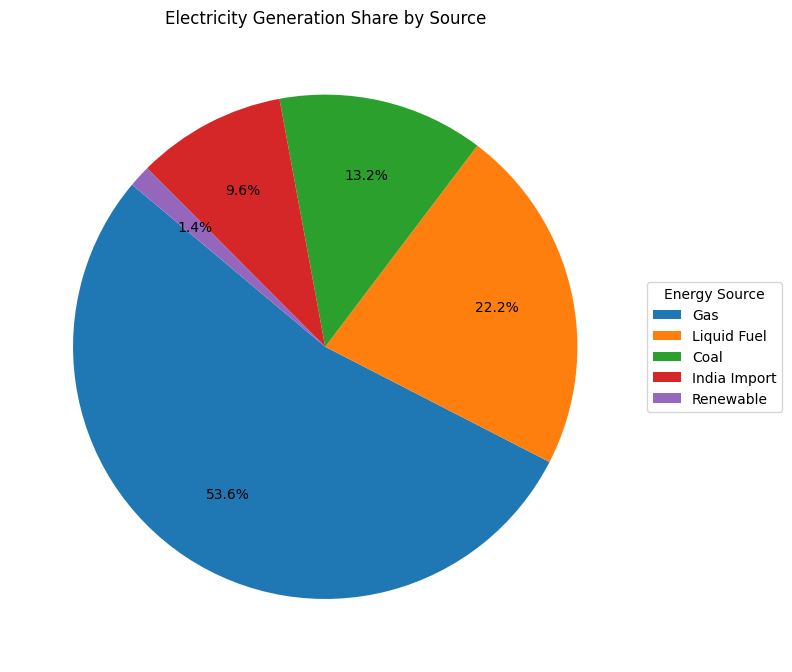

In [30]:
plt.figure(figsize=(8,8))

wedges, texts, autotexts = plt.pie(
    source_percent.values,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.7
)

# legend use instead of labels on pie
plt.legend(
    wedges,
    source_percent.index,
    title="Energy Source",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Electricity Generation Share by Source")

plt.tight_layout()
plt.savefig("plot.png", dpi=300, bbox_inches='tight')
from google.colab import files

files.download("plot.png")
plt.show()
plt.close()

In [31]:
# Renewable components
hydro = df['hydro'].sum()
solar = df['solar'].sum()
wind = df['wind'].sum()

# Create dictionary
renewable_sources = {
    'Hydro': hydro,
    'Solar': solar,
    'Wind': wind
}

# Convert to pandas series
renewable_series = pd.Series(renewable_sources)

# Total renewable generation
total_renewable = renewable_series.sum()

# Percentage within renewable
renewable_percent = (renewable_series / total_renewable) * 100

print(renewable_percent)

Hydro    62.425971
Solar    35.683511
Wind      1.890517
dtype: float64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

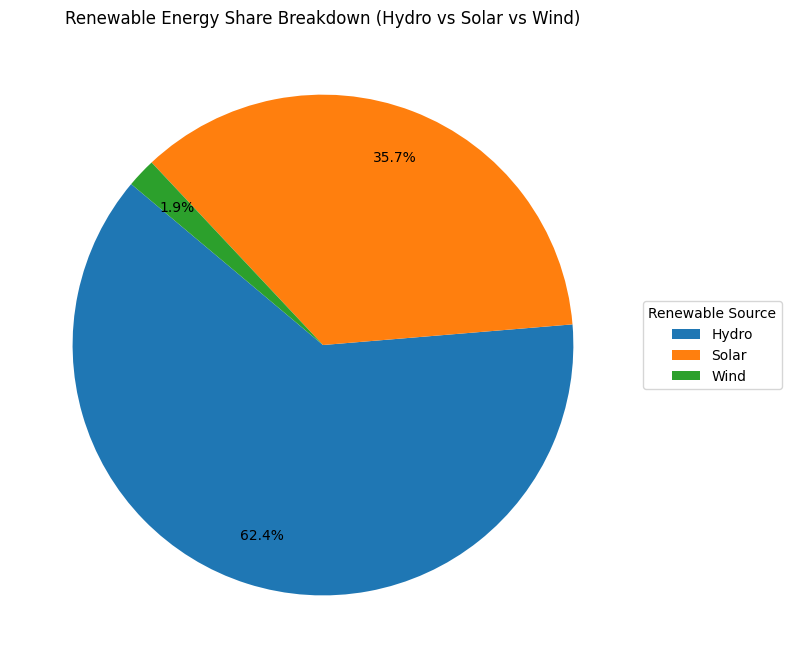

In [32]:
plt.figure(figsize=(8,8))

wedges, texts, autotexts = plt.pie(
    renewable_percent.values,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.8
)

plt.legend(
    wedges,
    renewable_percent.index,
    title="Renewable Source",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Renewable Energy Share Breakdown (Hydro vs Solar vs Wind)")

plt.tight_layout()
plt.savefig("plot.png", dpi=300, bbox_inches='tight')
from google.colab import files

files.download("plot.png")
plt.show()
plt.close()

In [33]:
cols_to_drop = [
     'load_shedding','liquid_fuel',
    'hydro', 'solar', 'wind',
    'india_bheramara_hvdc', 'india_bheramara_hvdc.1',
    'india_bheramara_hvdc.2', 'india_bheramara_hvdc.3',
    'remarks','year','generation_mw'
]

df.drop(columns=cols_to_drop, inplace=True)
df

,hour,month,demand_mw,gas,coal,Temperature_C,Humidity_%,Renewable_generation,India_import,temp_rolling_mean_24hr,demand_lag_1hr,demand_lag_24hr,demand_lag_48hr,demand_lag_168hr,demand_lag_336hr,demand_rolling_mean_24hr,sin_month,cos_month
datetime,,,,,,,,,,,,,,,,,,
2018-06-17 00:00:00,0,6,6832.0,5032,197,26.77,96.47,160.0,630.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.224647e-16,-1.0
2018-06-17 01:00:00,1,6,6526.0,4856,201,26.63,96.58,160.0,628.0,26.770000,6832.0,NaN,NaN,NaN,NaN,6832.000000,1.224647e-16,-1.0
2018-06-17 02:00:00,2,6,6264.0,4641,207,26.55,96.51,160.0,624.0,26.700000,6526.0,NaN,NaN,NaN,NaN,6679.000000,1.224647e-16,-1.0
2018-06-17 03:00:00,3,6,6217.0,4611,211,26.51,96.27,160.0,620.0,26.650000,6264.0,NaN,NaN,NaN,NaN,6540.666667,1.224647e-16,-1.0
2018-06-17 04:00:00,4,6,6128.0,4541,212,26.51,96.01,160.0,612.0,26.615000,6217.0,NaN,NaN,NaN,NaN,6459.750000,1.224647e-16,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,6,11896.0,5678,3470,28.74,87.73,408.0,1850.0,28.287917,11745.0,13155.0,13779.0,12403.0,14205.0,13856.458333,1.224647e-16,-1.0
2025-06-17 09:00:00,9,6,12290.0,6065,3491,29.37,84.07,351.0,1852.0,28.260000,11896.0,13569.0,14143.0,12072.0,14170.0,13804.000000,1.224647e-16,-1.0
2025-06-17 10:00:00,10,6,12443.0,5900,3601,29.77,81.71,418.0,1972.0,28.239583,12290.0,13816.0,14069.0,11377.0,13855.0,13750.708333,1.224647e-16,-1.0


In [34]:
df=df.dropna()
df

,hour,month,demand_mw,gas,coal,Temperature_C,Humidity_%,Renewable_generation,India_import,temp_rolling_mean_24hr,demand_lag_1hr,demand_lag_24hr,demand_lag_48hr,demand_lag_168hr,demand_lag_336hr,demand_rolling_mean_24hr,sin_month,cos_month
datetime,,,,,,,,,,,,,,,,,,
2018-06-30 08:00:00,8,6,7730.0,5473,122,28.43,88.54,170.4,584.0,28.090208,7103.0,6636.0,8247.0,8051.0,6832.0,8002.500000,1.224647e-16,-1.0
2018-06-30 09:00:00,9,6,7789.0,5288,149,29.15,85.46,171.2,586.0,28.051875,7730.0,6752.0,8288.0,7837.0,6526.0,8048.083333,1.224647e-16,-1.0
2018-06-30 10:00:00,10,6,7998.0,5296,158,29.77,82.79,171.1,587.0,28.014792,7789.0,7052.0,8621.0,7337.0,6264.0,8091.291667,1.224647e-16,-1.0
2018-06-30 11:00:00,11,6,8136.0,5192,157,30.18,81.13,172.0,580.0,27.984375,7998.0,7453.0,8651.0,8972.0,6217.0,8130.708333,1.224647e-16,-1.0
2018-06-30 12:00:00,12,6,8339.0,5104,153,30.50,79.89,172.3,578.0,27.963125,8136.0,7235.0,8837.0,10021.0,6128.0,8159.166667,1.224647e-16,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,6,11896.0,5678,3470,28.74,87.73,408.0,1850.0,28.287917,11745.0,13155.0,13779.0,12403.0,14205.0,13856.458333,1.224647e-16,-1.0
2025-06-17 09:00:00,9,6,12290.0,6065,3491,29.37,84.07,351.0,1852.0,28.260000,11896.0,13569.0,14143.0,12072.0,14170.0,13804.000000,1.224647e-16,-1.0
2025-06-17 10:00:00,10,6,12443.0,5900,3601,29.77,81.71,418.0,1972.0,28.239583,12290.0,13816.0,14069.0,11377.0,13855.0,13750.708333,1.224647e-16,-1.0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

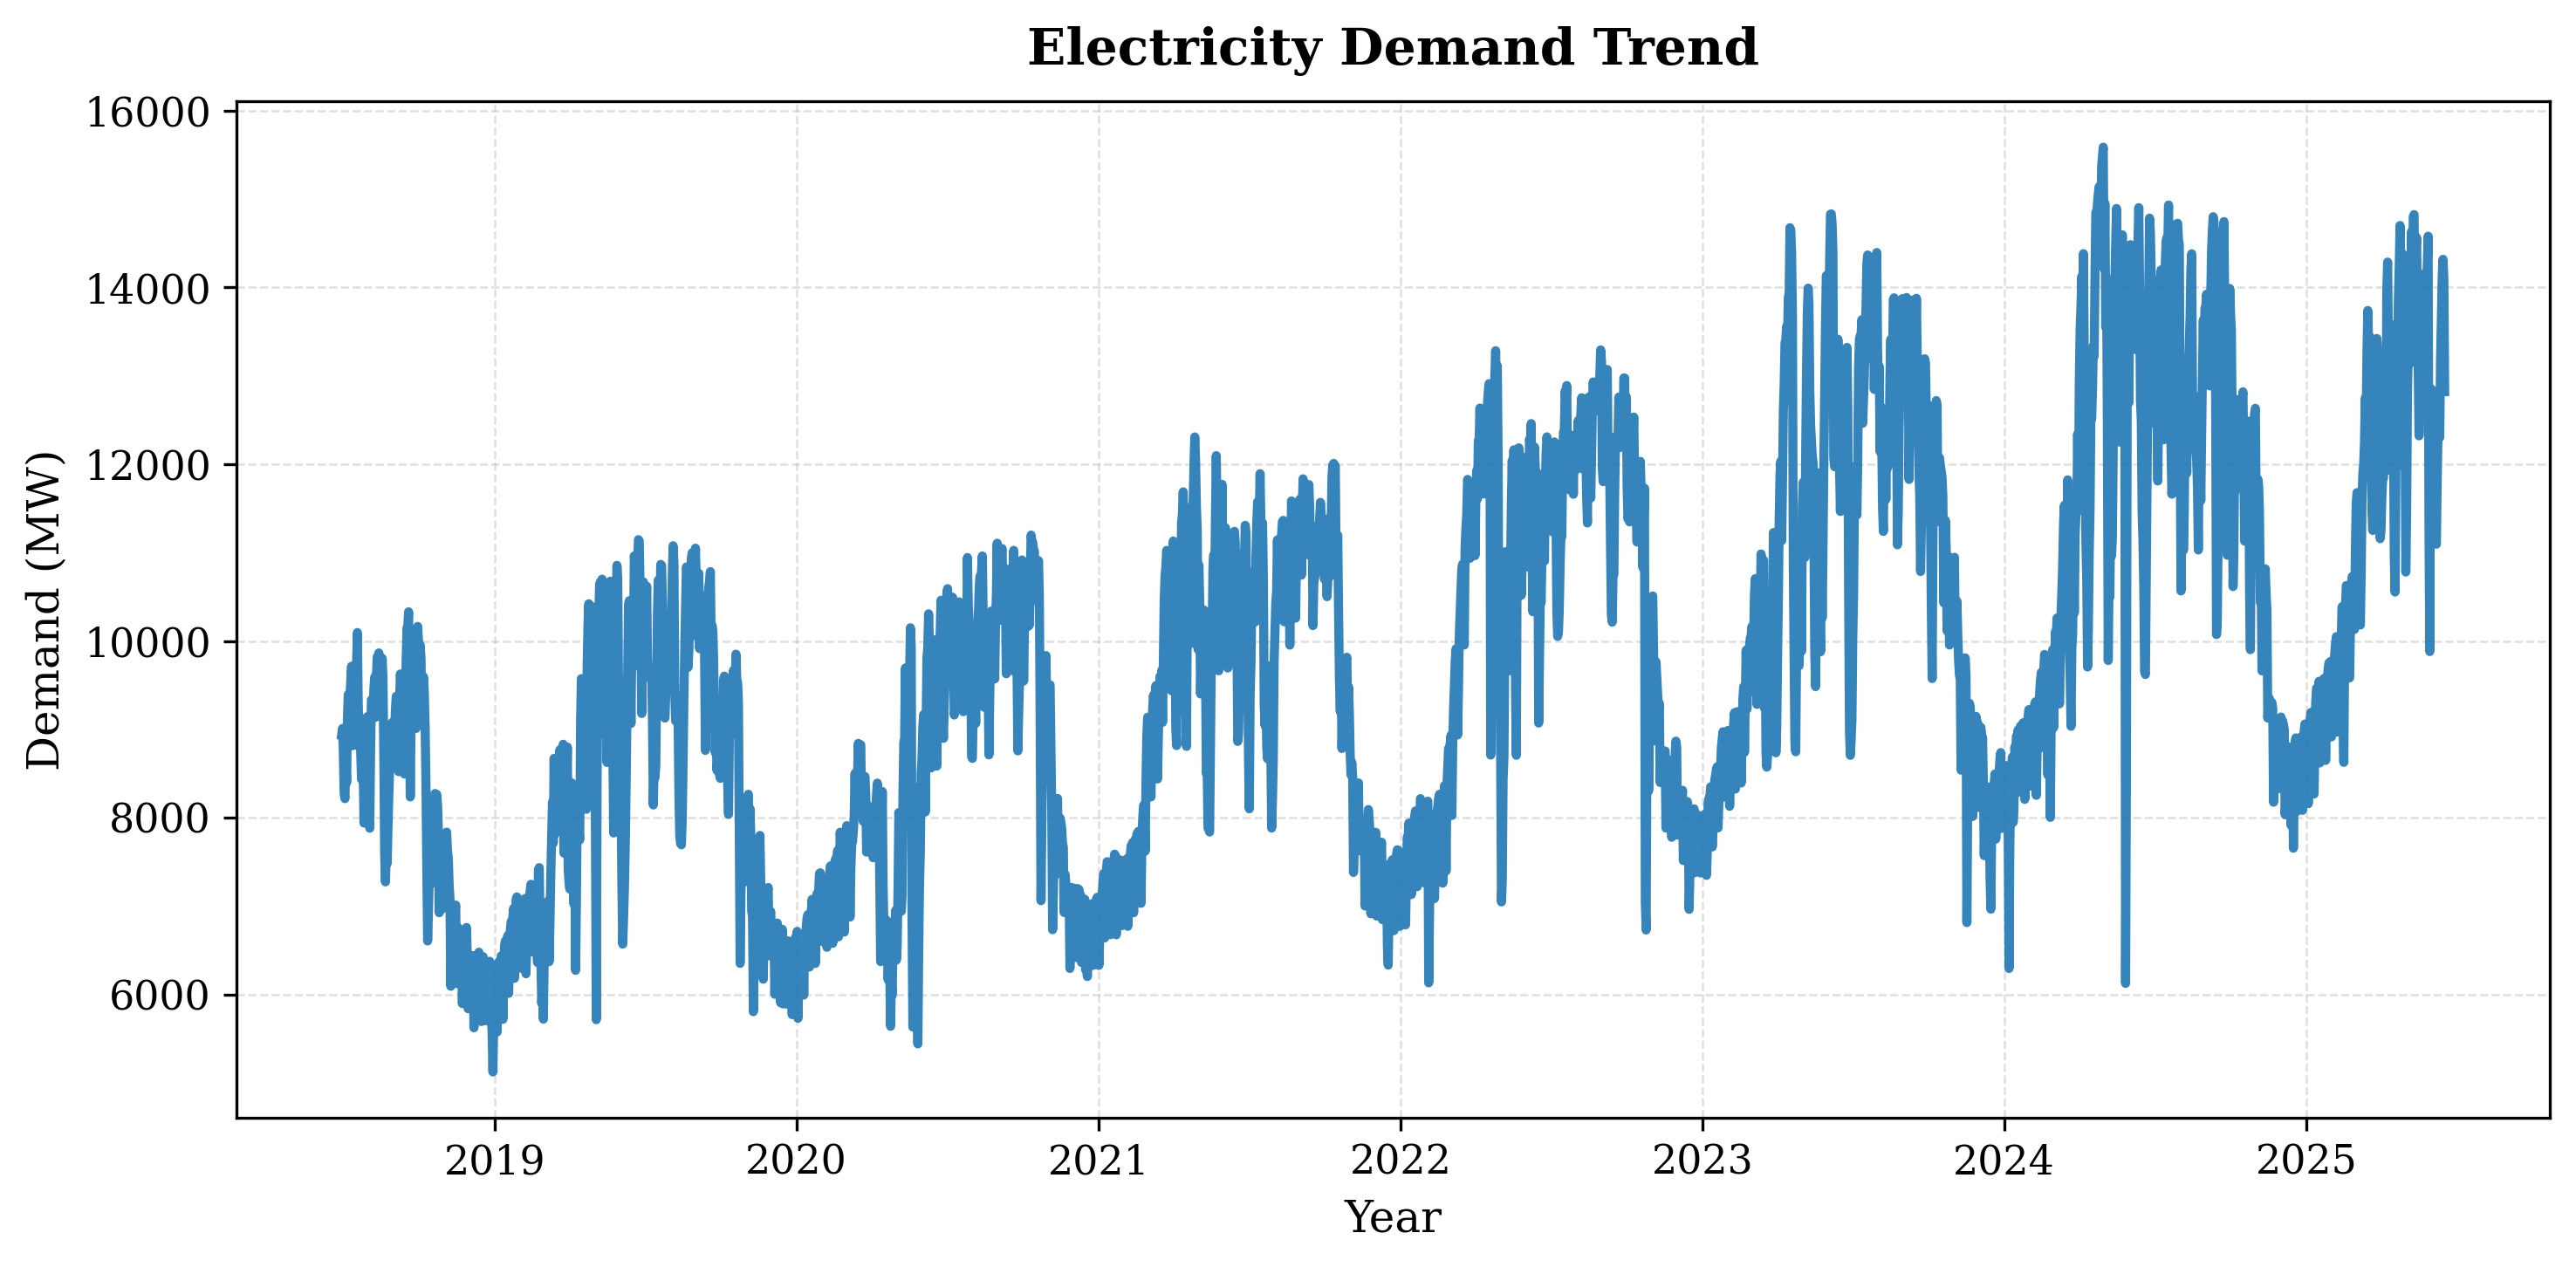

In [35]:
import matplotlib.pyplot as plt

df_daily = df['demand_mw'].resample('D').mean().interpolate()

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "axes.titleweight": "bold"
})


fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

ax.plot(
    df_daily.index,
    df_daily.values,
    color="#1f77b4",
    linewidth=2.5,
    alpha=0.9
)


ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.4)
ax.set_title("Electricity Demand Trend", pad=10)
ax.set_xlabel("Year")
ax.set_ylabel("Demand (MW)")
ax.tick_params(axis='both', which='major', labelsize=11)

plt.tight_layout()
plt.savefig("plot.png", dpi=300, bbox_inches='tight')
from google.colab import files

files.download("plot.png")
plt.show()
plt.close()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

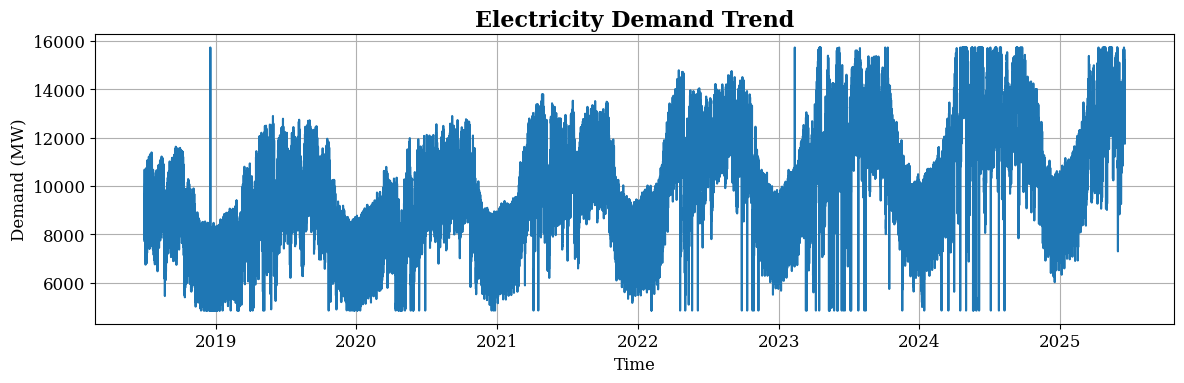

In [36]:
plt.figure(figsize=(12,4))

plt.plot(df['demand_mw'])

plt.title(
    "Electricity Demand Trend",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Time")
plt.ylabel("Demand (MW)")

plt.grid(True)
plt.tight_layout()
plt.savefig("plot.png", dpi=300, bbox_inches='tight')
from google.colab import files

files.download("plot.png")
plt.show()
plt.close()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

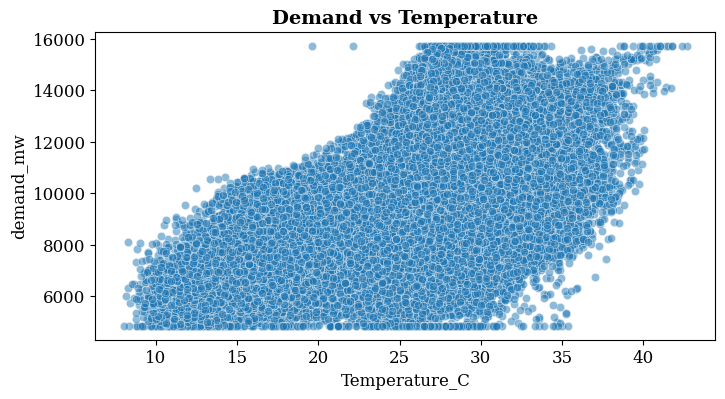

In [37]:
plt.figure(figsize=(8,4))
sns.scatterplot(data=df,x="Temperature_C",y="demand_mw",alpha=0.5)
plt.title("Demand vs Temperature")
plt.savefig("plot.png", dpi=300, bbox_inches='tight')
from google.colab import files

files.download("plot.png")
plt.show()
plt.close()

/tmp/ipykernel_10713/3854175359.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

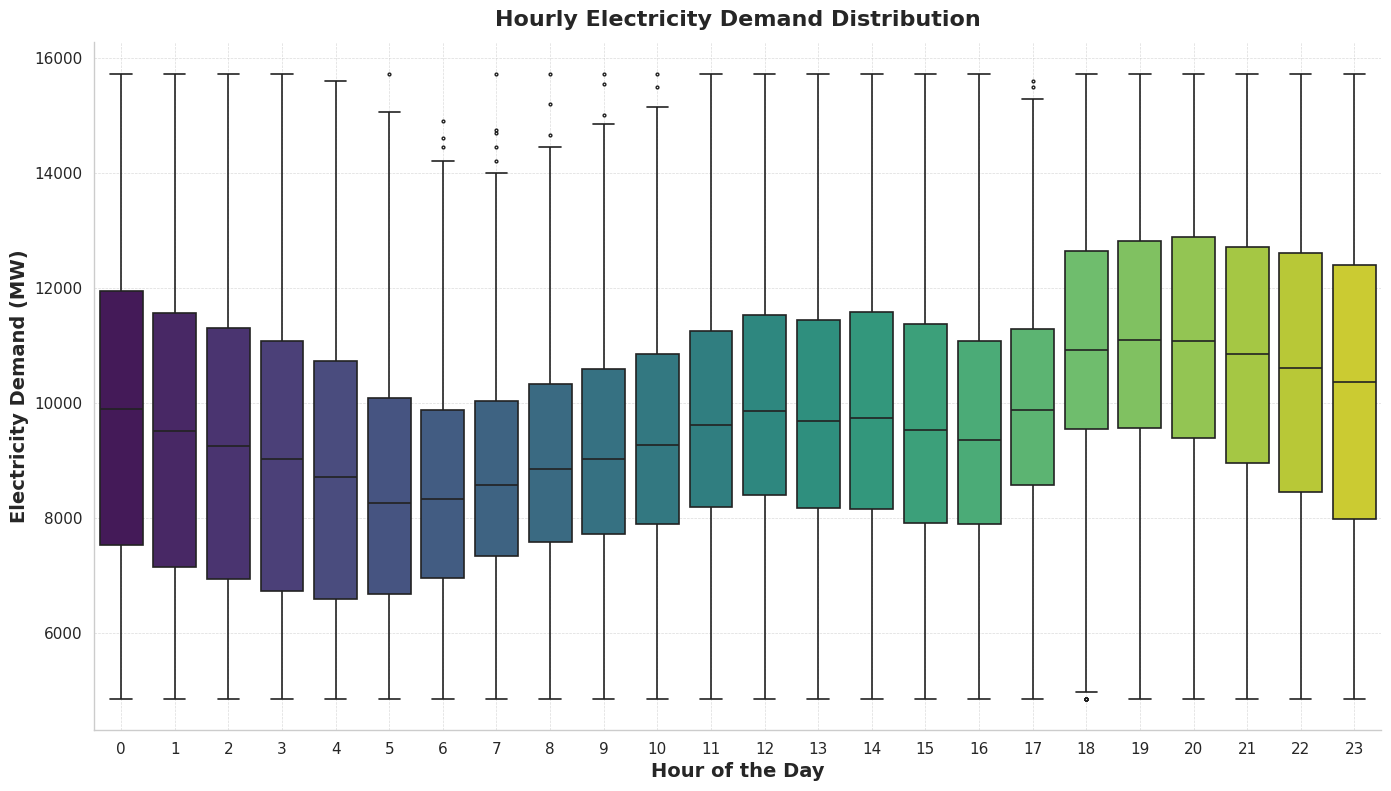

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="paper")

plt.figure(figsize=(14, 8))

ax = sns.boxplot(
    x="hour",
    y="demand_mw",
    data=df,
    palette="viridis",
    linewidth=1.2,
    fliersize=2
)


ax.set_xlabel("Hour of the Day", fontsize=14, fontweight='bold')
ax.set_ylabel("Electricity Demand (MW)", fontsize=14, fontweight='bold')

ax.set_title("Hourly Electricity Demand Distribution",
             fontsize=16, fontweight='bold', pad=12)

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

sns.despine()

ax.tick_params(axis='both', labelsize=11)

plt.tight_layout()

plt.savefig("plot.png", dpi=300, bbox_inches='tight')
from google.colab import files

files.download("plot.png")
plt.show()
plt.close()

/tmp/ipykernel_10713/1158230095.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

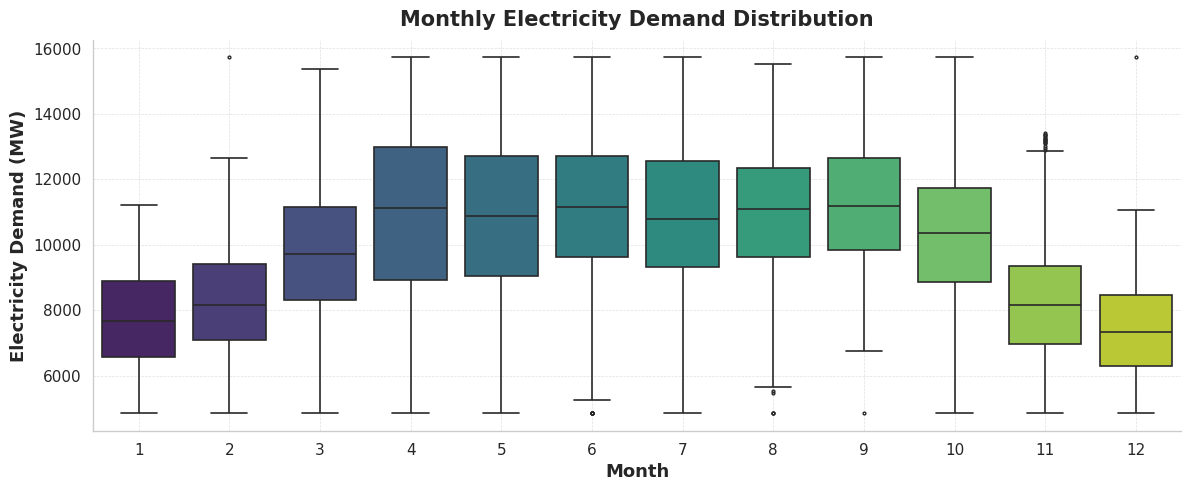

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="paper")

plt.figure(figsize=(12, 5))

ax = sns.boxplot(
    x="month",
    y="demand_mw",
    data=df,
    palette="viridis",
    linewidth=1.2,
    fliersize=2
    # showfliers=False     # optional (cleaner look)
)

# Labels
ax.set_xlabel("Month", fontsize=13, fontweight='bold')
ax.set_ylabel("Electricity Demand (MW)", fontsize=13, fontweight='bold')

# Title
ax.set_title("Monthly Electricity Demand Distribution",
             fontsize=15, fontweight='bold', pad=10)

# Subtle grid
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

# Clean edges
sns.despine()

# Tick formatting
ax.tick_params(axis='both', labelsize=11)

plt.tight_layout()

plt.savefig("plot.png", dpi=300, bbox_inches='tight')
from google.colab import files

files.download("plot.png")
plt.show()
plt.close()

In [40]:
df.columns

Index(['hour', 'month', 'demand_mw', 'gas', 'coal', 'Temperature_C',
       'Humidity_%', 'Renewable_generation', 'India_import',
       'temp_rolling_mean_24hr', 'demand_lag_1hr', 'demand_lag_24hr',
       'demand_lag_48hr', 'demand_lag_168hr', 'demand_lag_336hr',
       'demand_rolling_mean_24hr', 'sin_month', 'cos_month'],
      dtype='object')

In [41]:
cols_to_drop = [
     'month','hour',

]

df.drop(columns=cols_to_drop, inplace=True)
df

/tmp/ipykernel_10713/2911406120.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=cols_to_drop, inplace=True)


,demand_mw,gas,coal,Temperature_C,Humidity_%,Renewable_generation,India_import,temp_rolling_mean_24hr,demand_lag_1hr,demand_lag_24hr,demand_lag_48hr,demand_lag_168hr,demand_lag_336hr,demand_rolling_mean_24hr,sin_month,cos_month
datetime,,,,,,,,,,,,,,,,
2018-06-30 08:00:00,7730.0,5473,122,28.43,88.54,170.4,584.0,28.090208,7103.0,6636.0,8247.0,8051.0,6832.0,8002.500000,1.224647e-16,-1.0
2018-06-30 09:00:00,7789.0,5288,149,29.15,85.46,171.2,586.0,28.051875,7730.0,6752.0,8288.0,7837.0,6526.0,8048.083333,1.224647e-16,-1.0
2018-06-30 10:00:00,7998.0,5296,158,29.77,82.79,171.1,587.0,28.014792,7789.0,7052.0,8621.0,7337.0,6264.0,8091.291667,1.224647e-16,-1.0
2018-06-30 11:00:00,8136.0,5192,157,30.18,81.13,172.0,580.0,27.984375,7998.0,7453.0,8651.0,8972.0,6217.0,8130.708333,1.224647e-16,-1.0
2018-06-30 12:00:00,8339.0,5104,153,30.50,79.89,172.3,578.0,27.963125,8136.0,7235.0,8837.0,10021.0,6128.0,8159.166667,1.224647e-16,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,11896.0,5678,3470,28.74,87.73,408.0,1850.0,28.287917,11745.0,13155.0,13779.0,12403.0,14205.0,13856.458333,1.224647e-16,-1.0
2025-06-17 09:00:00,12290.0,6065,3491,29.37,84.07,351.0,1852.0,28.260000,11896.0,13569.0,14143.0,12072.0,14170.0,13804.000000,1.224647e-16,-1.0
2025-06-17 10:00:00,12443.0,5900,3601,29.77,81.71,418.0,1972.0,28.239583,12290.0,13816.0,14069.0,11377.0,13855.0,13750.708333,1.224647e-16,-1.0


In [42]:
df.columns

Index(['demand_mw', 'gas', 'coal', 'Temperature_C', 'Humidity_%',
       'Renewable_generation', 'India_import', 'temp_rolling_mean_24hr',
       'demand_lag_1hr', 'demand_lag_24hr', 'demand_lag_48hr',
       'demand_lag_168hr', 'demand_lag_336hr', 'demand_rolling_mean_24hr',
       'sin_month', 'cos_month'],
      dtype='object')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

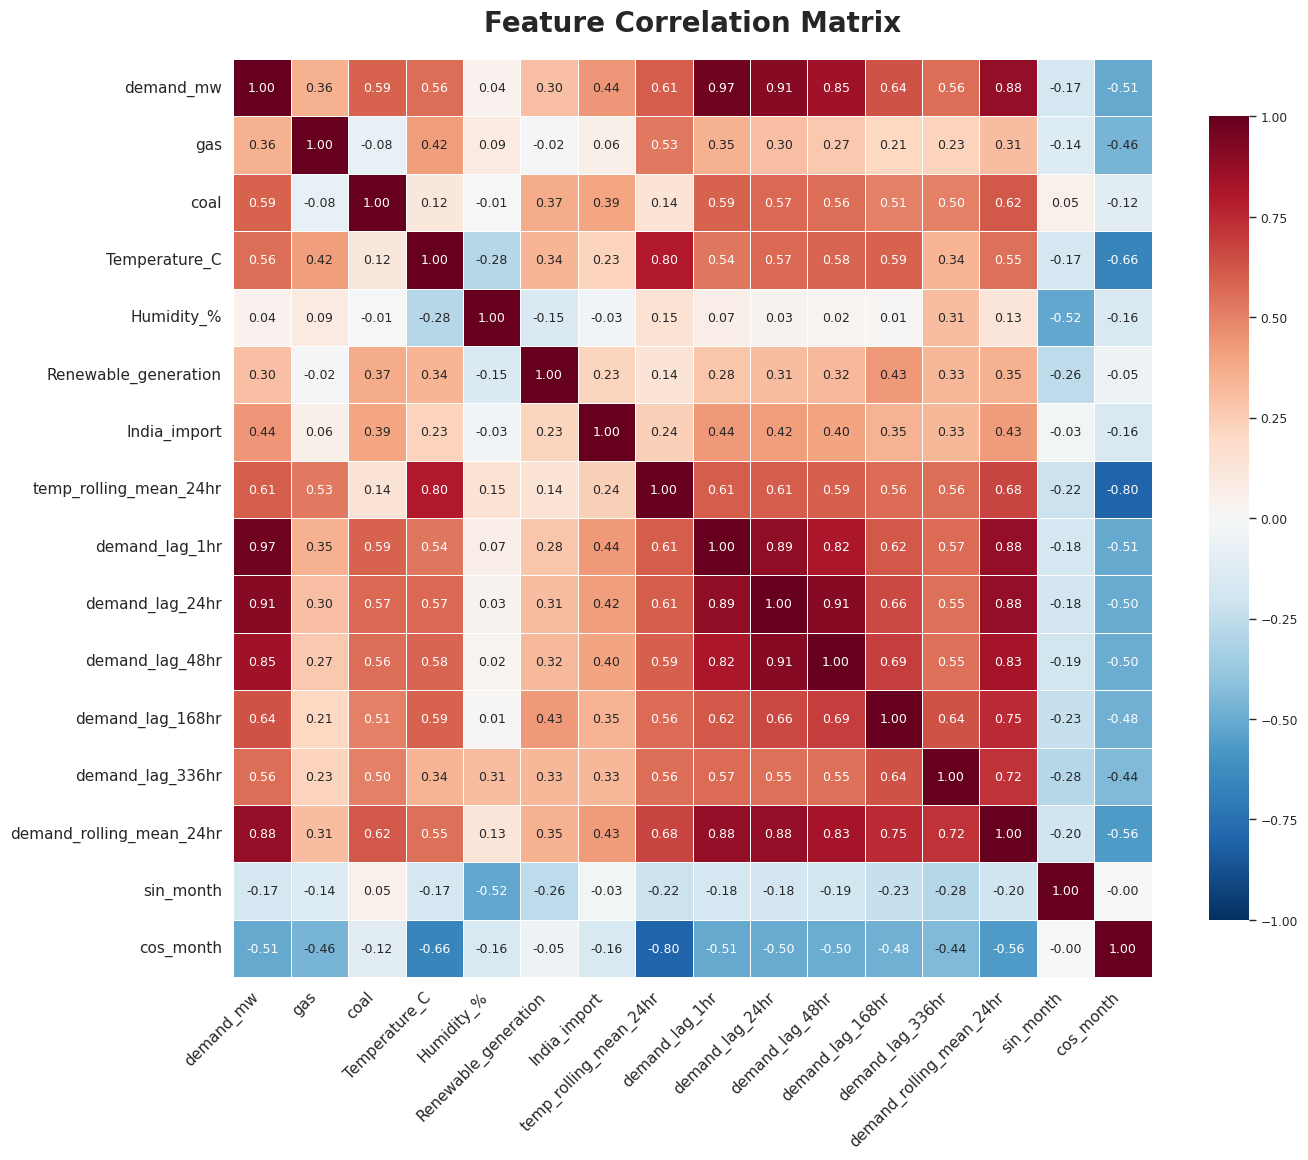

In [43]:
plt.figure(figsize=(14,12))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink":0.8},
    annot_kws={"size":9}
)

plt.title(
    "Feature Correlation Matrix",
    fontsize=20,
    fontweight='bold',
    pad=20
)

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.savefig("plot.png", dpi=300, bbox_inches='tight')
from google.colab import files

files.download("plot.png")
plt.show()
plt.close()


In [44]:
# Target
y = df["demand_mw"]

# Features
x = df.drop("demand_mw", axis=1)

print("X shape:", x.shape)
print("Y shape:", y.shape)

print("\nFeatures used:")
print(x.columns.tolist())

X shape: (63527, 15)
Y shape: (63527,)

Features used:
['gas', 'coal', 'Temperature_C', 'Humidity_%', 'Renewable_generation', 'India_import', 'temp_rolling_mean_24hr', 'demand_lag_1hr', 'demand_lag_24hr', 'demand_lag_48hr', 'demand_lag_168hr', 'demand_lag_336hr', 'demand_rolling_mean_24hr', 'sin_month', 'cos_month']


In [45]:
features = x.columns.tolist()
print(len(features))
print(features)

15
['gas', 'coal', 'Temperature_C', 'Humidity_%', 'Renewable_generation', 'India_import', 'temp_rolling_mean_24hr', 'demand_lag_1hr', 'demand_lag_24hr', 'demand_lag_48hr', 'demand_lag_168hr', 'demand_lag_336hr', 'demand_rolling_mean_24hr', 'sin_month', 'cos_month']


In [46]:
train_size = int(len(x) * 0.70)
val_size   = int(len(x) * 0.15)

x_train = x.iloc[:train_size]
y_train = y.iloc[:train_size]

x_val = x.iloc[train_size:train_size+val_size]
y_val = y.iloc[train_size:train_size+val_size]

x_test = x.iloc[train_size+val_size:]
y_test = y.iloc[train_size+val_size:]
print(x_train.shape, x_val.shape, x_test.shape)

(44468, 15) (9529, 15) (9530, 15)


In [47]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [48]:
sx = MinMaxScaler()
sy = MinMaxScaler()

x_train = pd.DataFrame(sx.fit_transform(x_train), columns=features)
x_val   = pd.DataFrame(sx.transform(x_val), columns=features)
x_test  = pd.DataFrame(sx.transform(x_test), columns=features)

y_train = sy.fit_transform(y_train.values.reshape(-1,1))
y_val   = sy.transform(y_val.values.reshape(-1,1))
y_test  = sy.transform(y_test.values.reshape(-1,1))

In [49]:

w = 24

def make_window(x, y, w):
    X, Y = [], []

    for i in range(len(x) - w):

        X.append(x.iloc[i:i+w].to_numpy())


        Y.append(y[i+w])

    X = np.array(X)
    Y = np.array(Y).reshape(-1, 1)

    return X, Y


# Apply to all splits
x_train_w, y_train_w = make_window(x_train, y_train, w)
x_val_w,   y_val_w   = make_window(x_val, y_val, w)
x_test_w,  y_test_w  = make_window(x_test, y_test, w)


# Print shapes
print("Train:", x_train_w.shape, y_train_w.shape)
print("Val  :", x_val_w.shape, y_val_w.shape)
print("Test :", x_test_w.shape, y_test_w.shape)

Train: (44444, 24, 15) (44444, 1)
Val  : (9505, 24, 15) (9505, 1)
Test : (9506, 24, 15) (9506, 1)


In [50]:
x_train_t = torch.tensor(x_train_w, dtype=torch.float32)
y_train_t = torch.tensor(y_train_w, dtype=torch.float32)

x_val_t = torch.tensor(x_val_w, dtype=torch.float32)
y_val_t = torch.tensor(y_val_w, dtype=torch.float32)

x_test_t = torch.tensor(x_test_w, dtype=torch.float32)
y_test_t = torch.tensor(y_test_w, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(x_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(x_val_t, y_val_t), batch_size=32, shuffle=False)
test_loader  = DataLoader(TensorDataset(x_test_t, y_test_t), batch_size=32, shuffle=False)

In [51]:
class CNN1D(nn.Module):
    def __init__(self, input_features):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(input_features, 64, kernel_size=3),
            nn.ReLU(),

            nn.Conv1d(64, 32, kernel_size=3),
            nn.ReLU(),

            nn.AdaptiveMaxPool1d(1)
        )

        self.bn = nn.BatchNorm1d(32)
        self.dropout = nn.Dropout(0.2)

        self.fc = nn.Sequential(
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv(x)
        x = x.squeeze(-1)
        x = self.bn(x)
        x = self.dropout(x)
        x = self.fc(x)
        return x

model = CNN1D(x_train_w.shape[2])

In [52]:
import torch.optim as optim
import torch.nn as nn

criterion = nn.HuberLoss(
    delta=1.0
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.0003,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

In [53]:
import time
epochs = 100

train_loss_list = []
val_loss_list = []

best_val = np.inf
patience = 15
counter = 0

start_time = time.time()

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for xb, yb in train_loader:

        optimizer.zero_grad()

        out = model(xb)

        loss = criterion(out, yb)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_loss = 0

    with torch.no_grad():

        for xb, yb in val_loader:

            out = model(xb)

            loss = criterion(out, yb)

            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    scheduler.step(val_loss)

    if val_loss < best_val:

        best_val = val_loss
        counter = 0

        torch.save(
            model.state_dict(),
            "best_model.pt"
        )

    else:
        counter += 1

    if counter >= patience:
        print("Early stopping")
        break

    if (epoch + 1) % 5 == 0:

        print(
            f"{epoch+1}/100 | Train:{train_loss:.6f} | Val:{val_loss:.6f}"
        )

print(
    "\nTOTAL TIME:",
    time.time() - start_time
)

model.load_state_dict(
    torch.load("best_model.pt")
)

5/100 | Train:0.003203 | Val:0.004708
10/100 | Train:0.002373 | Val:0.003566
15/100 | Train:0.002035 | Val:0.003116
20/100 | Train:0.001762 | Val:0.002867
25/100 | Train:0.001654 | Val:0.002862
30/100 | Train:0.001539 | Val:0.002585
35/100 | Train:0.001490 | Val:0.002559
40/100 | Train:0.001429 | Val:0.002587
45/100 | Train:0.001407 | Val:0.002532
50/100 | Train:0.001406 | Val:0.002577
55/100 | Train:0.001400 | Val:0.002563
60/100 | Train:0.001415 | Val:0.002574
65/100 | Train:0.001383 | Val:0.002554
Early stopping

TOTAL TIME: 467.6610734462738


<All keys matched successfully>

In [54]:
model.eval()
pred = []

with torch.no_grad():
    for xb, _ in test_loader:
        pred.append(model(xb).numpy())

y_pred = np.concatenate(pred).reshape(-1)
y_true = y_test_w.reshape(-1)

In [55]:
y_true_inv = sy.inverse_transform(y_true.reshape(-1,1))
y_pred_inv = sy.inverse_transform(y_pred.reshape(-1,1))

In [56]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_true_inv, y_pred_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_inv, y_pred_inv)
r2 = r2_score(y_true_inv, y_pred_inv)

eps = 1e-8
mape = np.mean(np.abs((y_true_inv - y_pred_inv) / (y_true_inv + eps))) * 100

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("MAPE:", mape)
print("R2  :", r2)

MSE : 436211.2602048113
RMSE: 660.4629135726027
MAE : 485.1525355840228
MAPE: 4.23333136202813
R2  : 0.9100864334891507


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

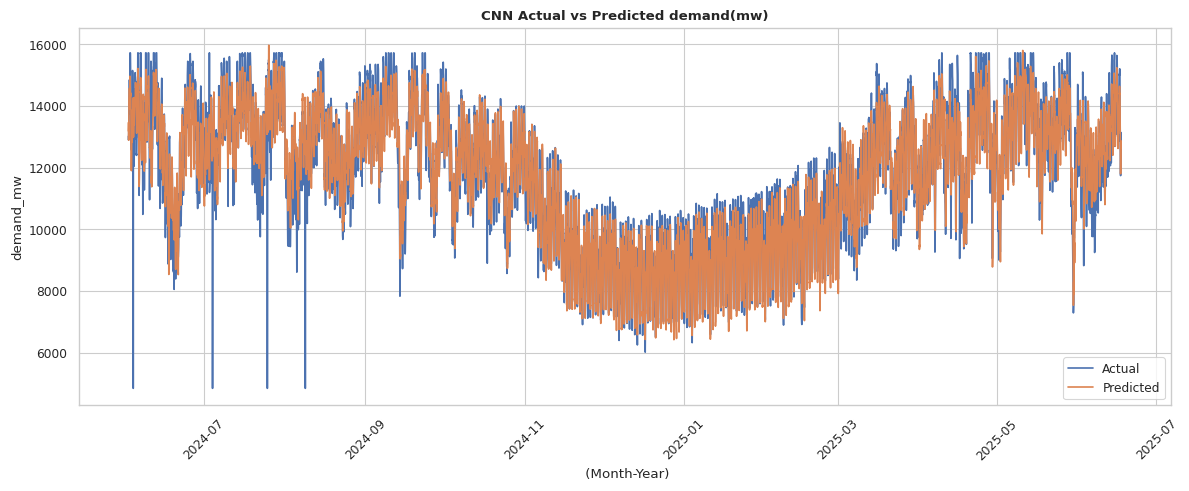

In [57]:

# time index fix
time_index = y.index[-len(y_true_inv):]

plt.figure(figsize=(12,5))
plt.plot(time_index, y_true_inv, label="Actual")
plt.plot(time_index, y_pred_inv, label="Predicted")

plt.title("CNN Actual vs Predicted demand(mw)")
plt.xlabel(" (Month-Year)")
plt.ylabel("demand_mw")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("plot.png", dpi=300, bbox_inches='tight')
from google.colab import files

files.download("plot.png")
plt.show()
plt.close()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

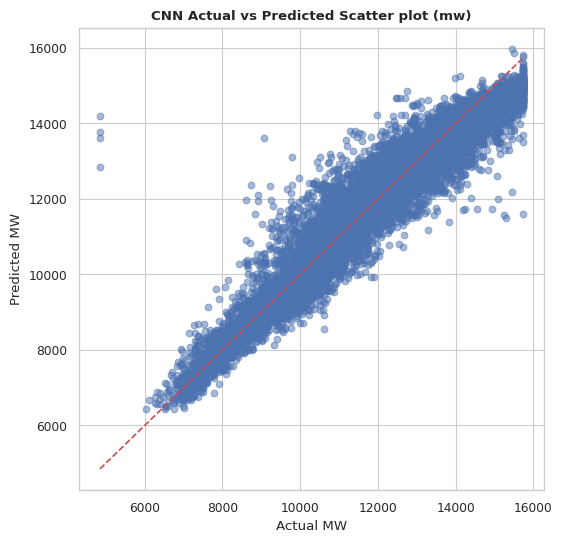

In [58]:
plt.figure(figsize=(6,6))
plt.scatter(y_true_inv, y_pred_inv, alpha=0.5)

plt.xlabel("Actual MW")
plt.ylabel("Predicted MW")
plt.title("CNN Actual vs Predicted Scatter plot (mw)")

# perfect line
plt.plot([y_true_inv.min(), y_true_inv.max()],
         [y_true_inv.min(), y_true_inv.max()],
         'r--')
plt.savefig("plot.png", dpi=300, bbox_inches='tight')
from google.colab import files

files.download("plot.png")
plt.show()
plt.close()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

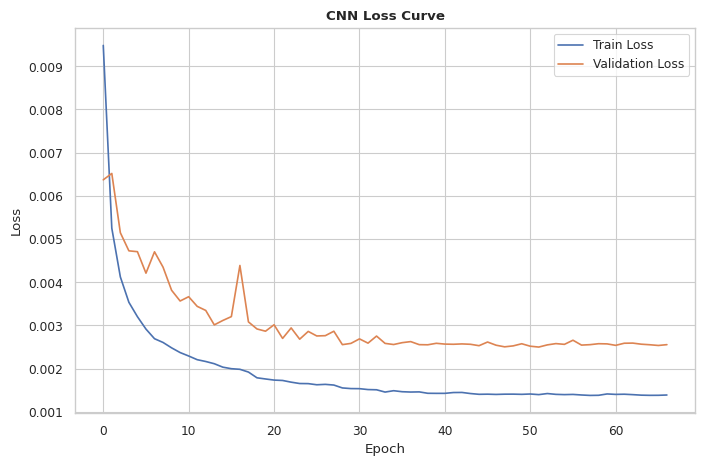

In [59]:
plt.figure(figsize=(8,5))

plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Validation Loss")

plt.title("CNN Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.savefig("plot.png", dpi=300, bbox_inches='tight')
from google.colab import files

files.download("plot.png")
plt.show()
plt.close()

#LSTM

In [60]:

class LSTMModel(nn.Module):
    def __init__(self, input_features):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_features,
            hidden_size=32,
            batch_first=True
        )

        self.dropout = nn.Dropout(0.2)

        self.fc = nn.Sequential(
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]   # last timestep
        out = self.dropout(out)
        out = self.fc(out)
        return out


model = LSTMModel(x_train_w.shape[2])

In [61]:

criterion = nn.HuberLoss(
    delta=1.0
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.0003,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

In [62]:

epochs = 100

train_loss_list = []
val_loss_list = []

best_val = np.inf
patience = 15
counter = 0

start_time = time.time()

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for xb, yb in train_loader:

        optimizer.zero_grad()

        out = model(xb)

        loss = criterion(out, yb)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_loss = 0

    with torch.no_grad():

        for xb, yb in val_loader:

            out = model(xb)

            loss = criterion(out, yb)

            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    scheduler.step(val_loss)

    if val_loss < best_val:

        best_val = val_loss
        counter = 0

        torch.save(
            model.state_dict(),
            "best_model.pt"
        )

    else:
        counter += 1

    if counter >= patience:
        print("Early stopping")
        break

    if (epoch + 1) % 5 == 0:

        print(
            f"{epoch+1}/100 | Train:{train_loss:.6f} | Val:{val_loss:.6f}"
        )

print(
    "\nTOTAL TIME:",
    time.time() - start_time
)

model.load_state_dict(
    torch.load("best_model.pt")
)

5/100 | Train:0.001119 | Val:0.001801
10/100 | Train:0.000935 | Val:0.002835
15/100 | Train:0.000865 | Val:0.002471
Early stopping

TOTAL TIME: 99.46656012535095


<All keys matched successfully>

In [63]:
model.eval()
pred = []

with torch.no_grad():
    for xb, _ in test_loader:
        pred.append(model(xb).cpu().numpy())

y_pred = np.concatenate(pred).reshape(-1)
y_true = y_test_w.reshape(-1)

In [64]:
y_true_inv = sy.inverse_transform(y_true.reshape(-1,1)).reshape(-1)
y_pred_inv = sy.inverse_transform(y_pred.reshape(-1,1)).reshape(-1)

In [65]:

mse = mean_squared_error(y_true_inv, y_pred_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_inv, y_pred_inv)
r2 = r2_score(y_true_inv, y_pred_inv)

eps = 1e-8
mape = np.mean(np.abs((y_true_inv - y_pred_inv) / (y_true_inv + eps))) * 100

print("LSTM PERFORMANCE")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("MAPE:", mape)
print("R2  :", r2)

LSTM PERFORMANCE
MSE : 271270.000081369
RMSE: 520.8358667386195
MAE : 369.1409547506181
MAPE: 3.21647282429409
R2  : 0.94408476942282


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

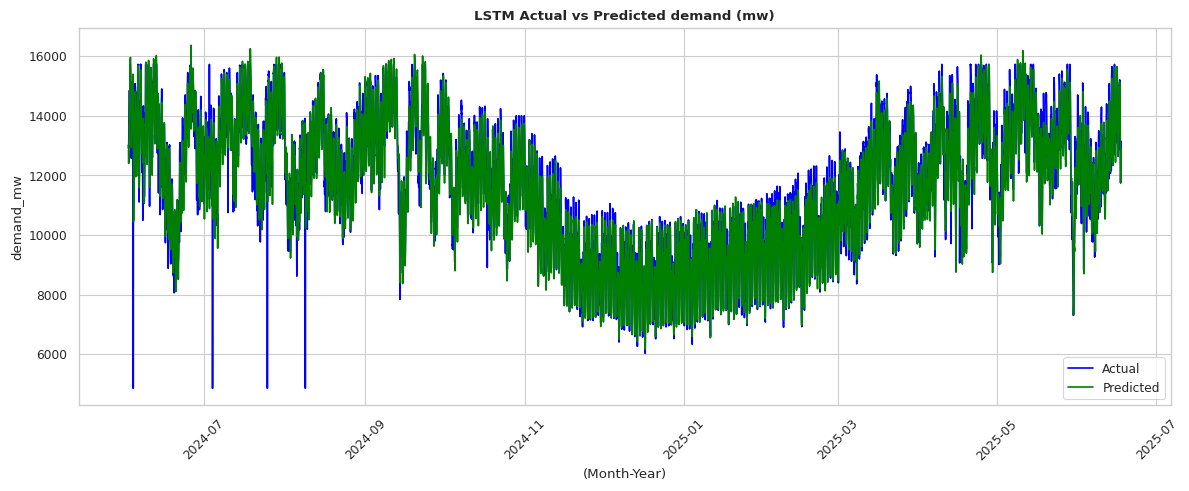

In [66]:

time_index = y.iloc[train_size + val_size + w:].index

plt.figure(figsize=(12,5))
plt.plot(time_index, y_true_inv,color="blue", label="Actual")
plt.plot(time_index, y_pred_inv,color="Green", label="Predicted")

plt.title("LSTM Actual vs Predicted demand (mw)")
plt.xlabel("(Month-Year)")
plt.ylabel("demand_mw")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("plot.png", dpi=300, bbox_inches='tight')
from google.colab import files

files.download("plot.png")
plt.show()
plt.close()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

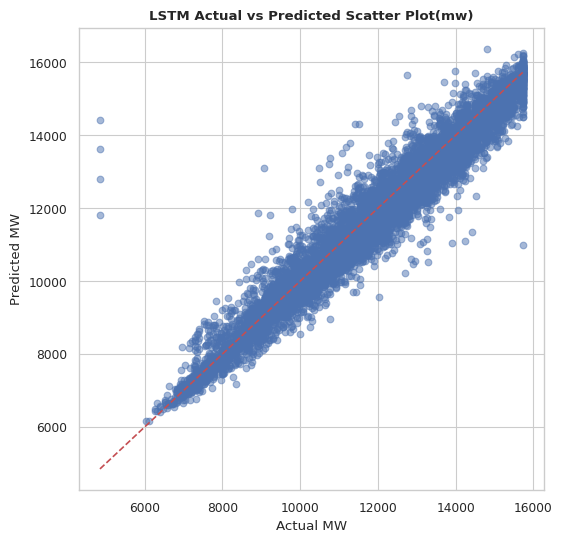

In [67]:
plt.figure(figsize=(6,6))
plt.scatter(y_true_inv, y_pred_inv, alpha=0.5)

plt.plot([y_true_inv.min(), y_true_inv.max()],
         [y_true_inv.min(), y_true_inv.max()],
         'r--')

plt.xlabel("Actual MW")
plt.ylabel("Predicted MW")
plt.title("LSTM Actual vs Predicted Scatter Plot(mw)")

plt.savefig("plot.png", dpi=300, bbox_inches='tight')
from google.colab import files

files.download("plot.png")
plt.show()
plt.close()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

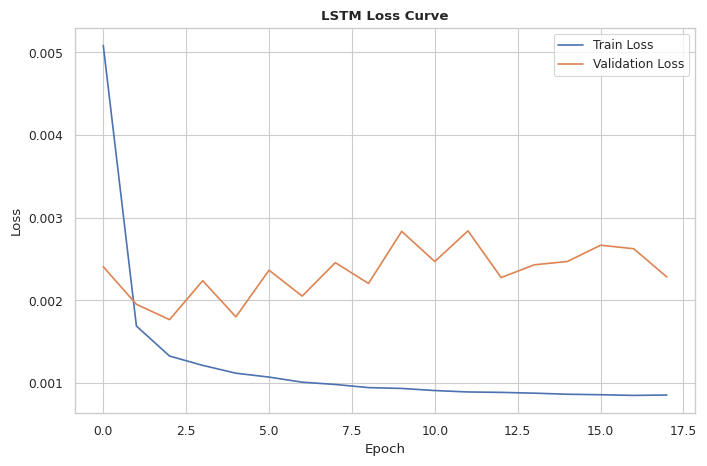

In [68]:
plt.figure(figsize=(8,5))

plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Validation Loss")

plt.title("LSTM Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.savefig("plot.png", dpi=300, bbox_inches='tight')
from google.colab import files

files.download("plot.png")
plt.show()
plt.close()

#CNN-BiLSTM Attention Hybried Model

In [69]:

class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (batch, time, hidden)
        weights = torch.softmax(self.attn(x), dim=1)   # (batch, time, 1)
        context = torch.sum(weights * x, dim=1)         # (batch, hidden)
        return context

In [70]:
class HybridModel(nn.Module):
    def __init__(self, input_features):
        super().__init__()

        # CNN branch
        self.cnn = nn.Sequential(
            nn.Conv1d(input_features, 64, kernel_size=3),
            nn.ReLU(),
            nn.Conv1d(64, 32, kernel_size=3),
            nn.ReLU(),
            nn.AdaptiveMaxPool1d(1)
        )
        self.cnn_dropout = nn.Dropout(0.3)

        # BiLSTM branch
        self.lstm = nn.LSTM(
            input_size=input_features,
            hidden_size=32,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
            dropout=0.25
        )
        self.attn = Attention(64)

        # Final
        self.bn = nn.BatchNorm1d(64+32)
        self.final_dropout=nn.Dropout(0.25)

        self.fc = nn.Sequential(
            nn.Linear(96, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # CNN branch
        x_cnn = x.permute(0,2,1)
        x_cnn = self.cnn(x_cnn).squeeze(-1)
        x_cnn = self.cnn_dropout(x_cnn)

        # LSTM branch
        x_lstm, _ = self.lstm(x)
        x_lstm = self.attn(x_lstm)

        # concat
        x = torch.cat((x_cnn, x_lstm), dim=1)
        x = self.bn(x)
        x=self.final_dropout(x)
        x = self.fc(x)

        return x


model = HybridModel(x_train_w.shape[2])

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.25 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


In [71]:

criterion = nn.HuberLoss(
    delta=1.0
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.0003,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

In [72]:

epochs = 100

train_loss_list = []
val_loss_list = []

best_val = np.inf
patience = 15
counter = 0

start_time = time.time()

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for xb, yb in train_loader:

        optimizer.zero_grad()

        out = model(xb)

        loss = criterion(out, yb)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_loss = 0

    with torch.no_grad():

        for xb, yb in val_loader:

            out = model(xb)

            loss = criterion(out, yb)

            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    scheduler.step(val_loss)

    if val_loss < best_val:

        best_val = val_loss
        counter = 0

        torch.save(
            model.state_dict(),
            "best_model.pt"
        )

    else:
        counter += 1

    if counter >= patience:
        print("Early stopping")
        break

    if (epoch + 1) % 5 == 0:

        print(
            f"{epoch+1}/100 | Train:{train_loss:.6f} | Val:{val_loss:.6f}"
        )

print(
    "\nTOTAL TIME:",
    time.time() - start_time
)

model.load_state_dict(
    torch.load("best_model.pt")
)

5/100 | Train:0.001766 | Val:0.002329
10/100 | Train:0.001301 | Val:0.001997
15/100 | Train:0.001122 | Val:0.001546
20/100 | Train:0.001042 | Val:0.001566
25/100 | Train:0.000962 | Val:0.001397
30/100 | Train:0.000906 | Val:0.001703
35/100 | Train:0.000860 | Val:0.001484
40/100 | Train:0.000808 | Val:0.001262
45/100 | Train:0.000763 | Val:0.001283
50/100 | Train:0.000743 | Val:0.001315
Early stopping

TOTAL TIME: 789.3752448558807


<All keys matched successfully>

In [73]:
model.eval()
pred = []

with torch.no_grad():
    for xb, _ in test_loader:
        pred.append(model(xb).cpu().numpy())

y_pred = np.concatenate(pred).reshape(-1)
y_true = y_test_w.reshape(-1)

In [74]:
y_true_inv = sy.inverse_transform(y_true.reshape(-1,1)).reshape(-1)
y_pred_inv = sy.inverse_transform(y_pred.reshape(-1,1)).reshape(-1)

mse = mean_squared_error(y_true_inv, y_pred_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_inv, y_pred_inv)
r2 = r2_score(y_true_inv, y_pred_inv)

mape = np.mean(np.abs((y_true_inv - y_pred_inv)/(y_true_inv+1e-8))) * 100

print("HYBRID PERFORMANCE")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("MAPE:", mape)
print("R2  :", r2)

HYBRID PERFORMANCE
MSE : 197457.49282885453
RMSE: 444.36189398828355
MAE : 288.6497562949553
MAPE: 2.5868216961885557
R2  : 0.9592992913429222


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

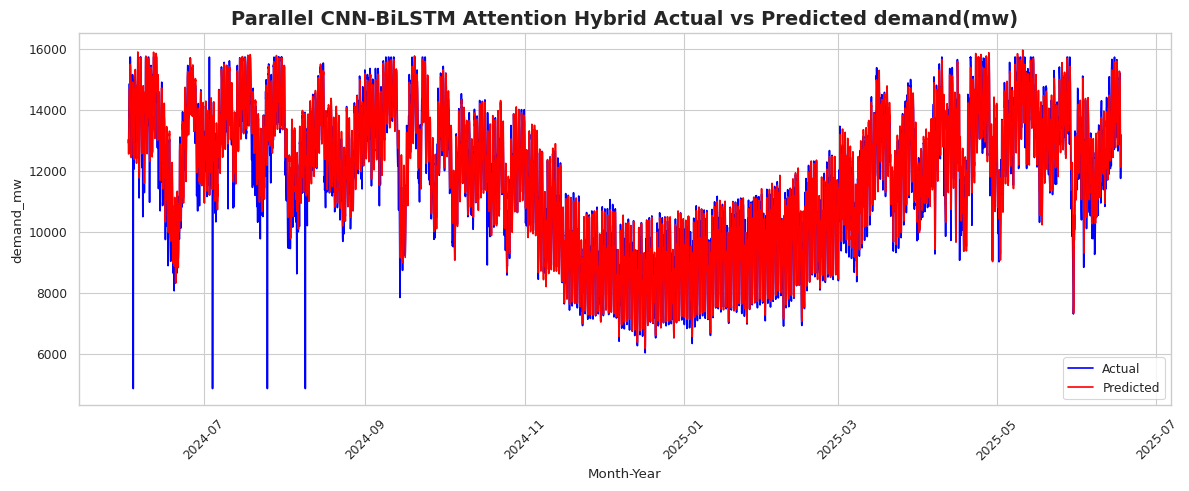

In [75]:

# correct time index
time_index = y.iloc[train_size + val_size + w:].index

# convert to Year-Month format
time_index = pd.to_datetime(time_index)

plt.figure(figsize=(12,5))

plt.plot(time_index, y_true_inv, color='blue', label="Actual")

plt.plot(time_index, y_pred_inv, color='red', label="Predicted")
plt.title(
    "Parallel CNN-BiLSTM Attention Hybrid Actual vs Predicted demand(mw)",
    fontsize=14,
    fontweight='bold'

)
plt.xlabel("Month-Year")
plt.ylabel("demand_mw")

# format x-axis as Year-Month
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()
plt.savefig("plot.png", dpi=300, bbox_inches='tight')
from google.colab import files

files.download("plot.png")
plt.show()
plt.close()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

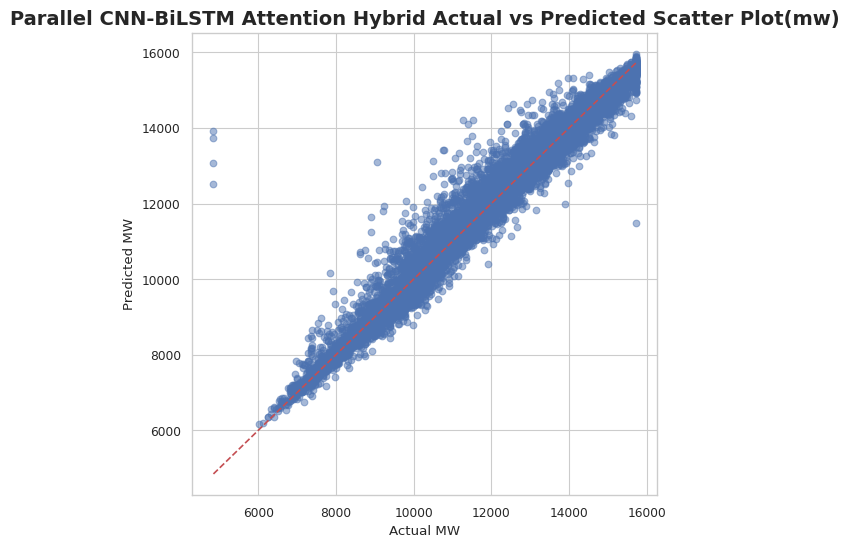

In [76]:
plt.figure(figsize=(6,6))
plt.scatter(y_true_inv, y_pred_inv, alpha=0.5)

plt.plot([y_true_inv.min(), y_true_inv.max()],
         [y_true_inv.min(), y_true_inv.max()],
         'r--')
plt.xlabel("Actual MW")
plt.ylabel("Predicted MW")
plt.title(
    "Parallel CNN-BiLSTM Attention Hybrid Actual vs Predicted Scatter Plot(mw)",
    fontsize=14,
    fontweight='bold'

)
plt.savefig("plot.png", dpi=300, bbox_inches='tight')
from google.colab import files

files.download("plot.png")
plt.show()
plt.close()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

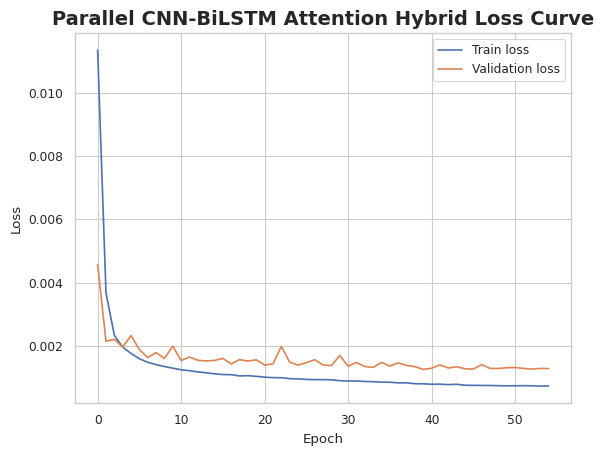

In [77]:
plt.plot(train_loss_list, label="Train loss")
plt.plot(val_loss_list, label="Validation loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "Parallel CNN-BiLSTM Attention Hybrid Loss Curve",
    fontsize=14,
    fontweight='bold'

)
plt.savefig("plot.png", dpi=300, bbox_inches='tight')
from google.colab import files

files.download("plot.png")
plt.show()
plt.close()


In [78]:
!pip install shap

In [79]:
import shap

In [80]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

#  LSTM backward fix
torch.backends.cudnn.enabled = False

#  Disable dropout randomness
def disable_dropout(m):
    if isinstance(m, torch.nn.Dropout):
        m.p = 0

model.apply(disable_dropout)

#  SHAP needs gradient
model.train()

HybridModel(
  (cnn): Sequential(
    (0): Conv1d(15, 64, kernel_size=(3,), stride=(1,))
    (1): ReLU()
    (2): Conv1d(64, 32, kernel_size=(3,), stride=(1,))
    (3): ReLU()
    (4): AdaptiveMaxPool1d(output_size=1)
  )
  (cnn_dropout): Dropout(p=0, inplace=False)
  (lstm): LSTM(15, 32, batch_first=True, dropout=0.25, bidirectional=True)
  (attn): Attention(
    (attn): Linear(in_features=64, out_features=1, bias=True)
  )
  (bn): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (final_dropout): Dropout(p=0, inplace=False)
  (fc): Sequential(
    (0): Linear(in_features=96, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [81]:
train_batch = next(iter(train_loader))
background_data, _ = train_batch

# 100 samples enough
background_data = background_data[:100].to(device)

print("Background shape:", background_data.shape)

Background shape: torch.Size([32, 24, 15])


In [82]:
explainer = shap.GradientExplainer(model, background_data)
print(" Explainer Ready")

 Explainer Ready


In [83]:
val_batch = next(iter(val_loader))
test_inputs, _ = val_batch

# small batch for stability
test_inputs = test_inputs[:30].to(device)
test_inputs.requires_grad = True

#  SHAP calculation
shap_values = explainer.shap_values(test_inputs)

# multi-output fix
if isinstance(shap_values, list):
    shap_values = shap_values[0]

print("SHAP raw shape:", np.array(shap_values).shape)

SHAP raw shape: (30, 24, 15, 1)


In [84]:
# Convert to numpy
shap_values_np = shap_values if isinstance(shap_values, np.ndarray) else shap_values.cpu().numpy()
test_inputs_np = test_inputs.detach().cpu().numpy()

print("Before fix:", shap_values_np.shape)

#  REMOVE extra dimension
if shap_values_np.shape[-1] == 1:
    shap_values_np = np.squeeze(shap_values_np, axis=-1)

print("After fix:", shap_values_np.shape)

Before fix: (30, 24, 15, 1)
After fix: (30, 24, 15)


In [85]:
shap_values_2d = np.mean(shap_values_np, axis=1)
test_inputs_2d = np.mean(test_inputs_np, axis=1)

print("Final SHAP shape:", shap_values_2d.shape)
print("Final Input shape:", test_inputs_2d.shape)

Final SHAP shape: (30, 15)
Final Input shape: (30, 15)


In [86]:
features=(['gas', 'coal', 'Temperature_C', 'Humidity_%',
       'Renewable_generation', 'India_import', 'temp_rolling_mean_24hr',
       'demand_lag_1hr', 'demand_lag_24hr', 'demand_lag_48hr',
       'demand_lag_168hr', 'demand_lag_336hr', 'demand_rolling_mean_24hr',
       'sin_month', 'cos_month'])

In [87]:
feature_names = features

print("Feature names length:", len(feature_names))
print("Model input features:", x_test_w.shape[-1])

Feature names length: 15
Model input features: 15


/tmp/ipykernel_10713/2447553010.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


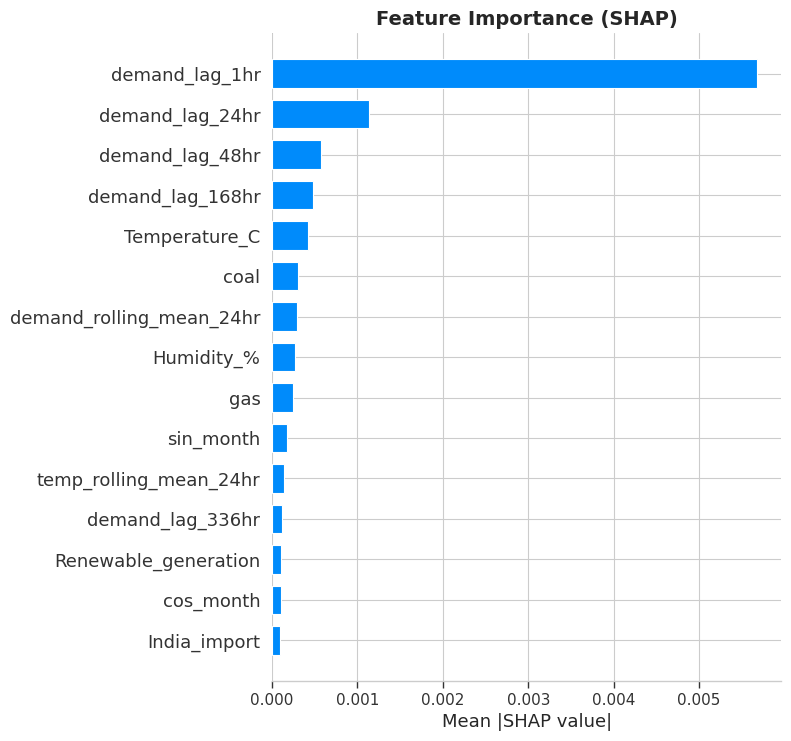

In [88]:
# ensure numpy array
shap_values_2d = np.array(shap_values_2d)
test_inputs_2d = np.array(test_inputs_2d)

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values_2d,
    test_inputs_2d,
    feature_names=features,
    plot_type="bar",
    show=False
)

plt.title("Feature Importance (SHAP)",
          fontsize=14, fontweight="bold")

plt.xlabel("Mean |SHAP value|")
plt.tight_layout()

plt.savefig("shap_bar.png", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_10713/2353461739.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

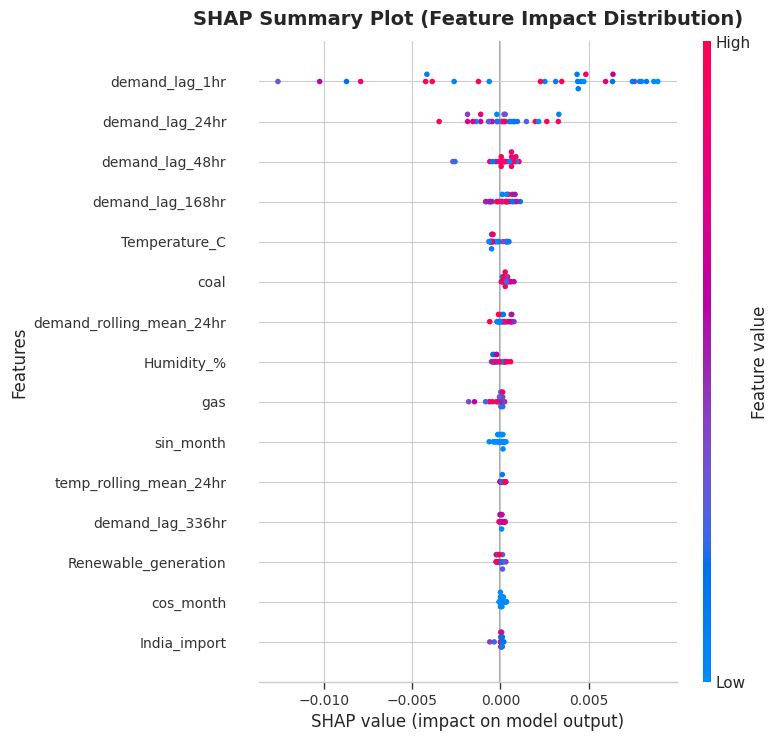

In [89]:
# Paper quality figure setup
plt.figure(figsize=(11, 6))

# SHAP beeswarm plot
shap.summary_plot(
    shap_values_2d,
    test_inputs_2d,
    feature_names=features,
    show=False
)

# Title (paper style)
plt.title("SHAP Summary Plot (Feature Impact Distribution)",
          fontsize=14, fontweight='bold', pad=12)

# Clean axis labels (optional for paper clarity)
plt.xlabel("SHAP value (impact on model output)", fontsize=12)
plt.ylabel("Features", fontsize=12)

# Improve readability
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()

plt.savefig("plot.png", dpi=300, bbox_inches='tight')
from google.colab import files

files.download("plot.png")
plt.show()
plt.close()

#CNN-LSTM

In [90]:

class CNN_LSTM(nn.Module):
    def __init__(self, input_features):
        super().__init__()

        # CNN
        self.conv1 = nn.Conv1d(input_features, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(64, 32, kernel_size=3, padding=1)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

        # LSTM
        self.lstm = nn.LSTM(
            input_size=32,
            hidden_size=32,
            batch_first=True
        )
        self.dropout_lstm=nn.Dropout(0.25)
        self.bn = nn.BatchNorm1d(32)
        self.final_dropout=nn.Dropout(0.25)
        # Dense
        self.fc = nn.Sequential(
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x: (batch, time, features)

        # CNN expects (batch, features, time)
        x = x.permute(0,2,1)

        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))

        x = self.dropout(x)

        # back to (batch, time, features)
        x = x.permute(0,2,1)

        # LSTM
        out, _ = self.lstm(x)
        out = out[:, -1, :]   # last timestep

        out = self.bn(out)
        out = self.fc(out)

        return out


model = CNN_LSTM(x_train_w.shape[2])

In [91]:

criterion = nn.HuberLoss(
    delta=1.0
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.0003,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

In [92]:

epochs = 100

train_loss_list = []
val_loss_list = []

best_val = np.inf
patience = 15
counter = 0

start_time = time.time()

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for xb, yb in train_loader:

        optimizer.zero_grad()

        out = model(xb)

        loss = criterion(out, yb)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_loss = 0

    with torch.no_grad():

        for xb, yb in val_loader:

            out = model(xb)

            loss = criterion(out, yb)

            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    scheduler.step(val_loss)

    if val_loss < best_val:

        best_val = val_loss
        counter = 0

        torch.save(
            model.state_dict(),
            "best_model.pt"
        )

    else:
        counter += 1

    if counter >= patience:
        print("Early stopping")
        break

    if (epoch + 1) % 5 == 0:

        print(
            f"{epoch+1}/100 | Train:{train_loss:.6f} | Val:{val_loss:.6f}"
        )

print(
    "\nTOTAL TIME:",
    time.time() - start_time
)

model.load_state_dict(
    torch.load("best_model.pt")
)

5/100 | Train:0.001196 | Val:0.001929
10/100 | Train:0.000945 | Val:0.002319
15/100 | Train:0.000765 | Val:0.001644
20/100 | Train:0.000710 | Val:0.002344
25/100 | Train:0.000676 | Val:0.002052
30/100 | Train:0.000655 | Val:0.001809
Early stopping

TOTAL TIME: 360.9982359409332


<All keys matched successfully>

In [93]:
model.eval()
pred = []

with torch.no_grad():
    for xb, _ in test_loader:
        pred.append(model(xb).cpu().numpy())

y_pred = np.concatenate(pred).reshape(-1)
y_true = y_test_w.reshape(-1)

In [94]:
y_true_inv = sy.inverse_transform(y_true.reshape(-1,1)).reshape(-1)
y_pred_inv = sy.inverse_transform(y_pred.reshape(-1,1)).reshape(-1)

mse = mean_squared_error(y_true_inv, y_pred_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_inv, y_pred_inv)
r2 = r2_score(y_true_inv, y_pred_inv)

mape = np.mean(np.abs((y_true_inv - y_pred_inv)/(y_true_inv+1e-8))) * 100

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("MAPE:", mape)
print("R2  :", r2)

MSE : 243730.7466086241
RMSE: 493.6909424008345
MAE : 353.8523735666949
MAPE: 2.9933746134236996
R2  : 0.9497612677727668


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

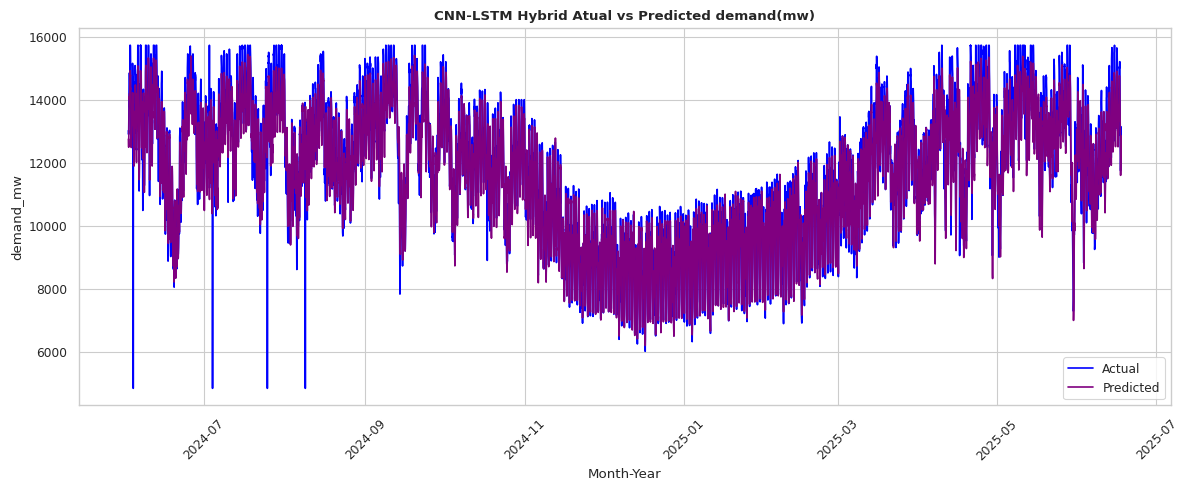

In [95]:

# correct time index
time_index = y.iloc[train_size + val_size + w:].index

# convert to Year-Month format
time_index = pd.to_datetime(time_index)

plt.figure(figsize=(12,5))

#  Actual = BLUE
plt.plot(time_index, y_true_inv, color='blue', label="Actual")

#  Predicted = RED
plt.plot(time_index, y_pred_inv, color='purple', label="Predicted")

plt.title("CNN-LSTM Hybrid Atual vs Predicted demand(mw)")
plt.xlabel("Month-Year")
plt.ylabel("demand_mw")

# format x-axis as Year-Month
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()
plt.savefig("plot.png", dpi=300, bbox_inches='tight')
from google.colab import files

files.download("plot.png")
plt.show()
plt.close()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

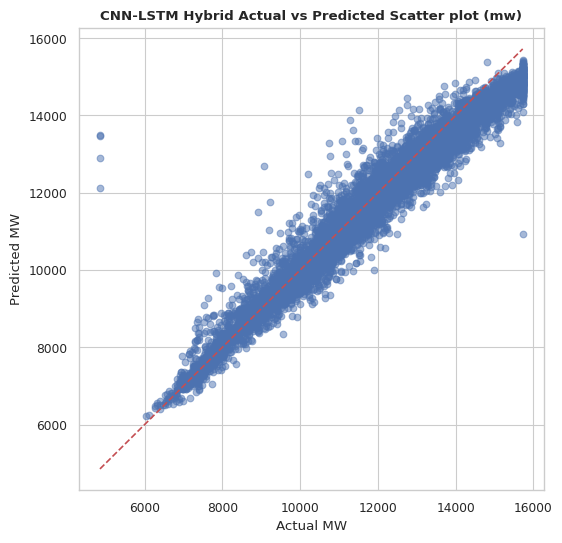

In [96]:
plt.figure(figsize=(6,6))
plt.scatter(y_true_inv, y_pred_inv, alpha=0.5)

plt.plot([y_true_inv.min(), y_true_inv.max()],
         [y_true_inv.min(), y_true_inv.max()],
         'r--')
plt.xlabel("Actual MW")
plt.ylabel("Predicted MW")
plt.title("CNN-LSTM Hybrid Actual vs Predicted Scatter plot (mw)")
plt.savefig("plot.png", dpi=300, bbox_inches='tight')
from google.colab import files

files.download("plot.png")
plt.show()
plt.close()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

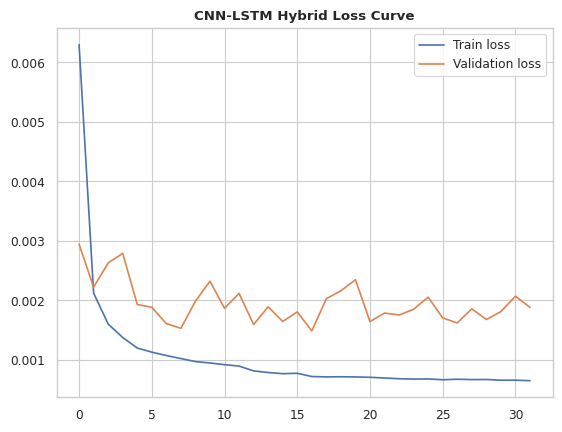

In [97]:
plt.plot(train_loss_list, label="Train loss")
plt.plot(val_loss_list, label="Validation loss")
plt.legend()
plt.title("CNN-LSTM Hybrid Loss Curve")
plt.savefig("plot.png", dpi=300, bbox_inches='tight')
from google.colab import files

files.download("plot.png")
plt.show()
plt.close()

#CNN-BiLSTM

In [98]:

class CNN_BiLSTM(nn.Module):
    def __init__(self, input_features):
        super().__init__()

        # CNN Branch
        self.conv = nn.Sequential(
            nn.Conv1d(input_features, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(64, 32, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.pool = nn.AdaptiveMaxPool1d(1)
        self.dropout_cnn = nn.Dropout(0.3)

        # BiLSTM Branch
        self.bilstm = nn.LSTM(
            input_size=input_features,
            hidden_size=32,
            batch_first=True,
            bidirectional=True
        )

        self.dropout_lstm = nn.Dropout(0.25)

        # Final
        self.bn = nn.BatchNorm1d(64 +32)
        self.final_dropout=nn.Dropout(0.25)
        self.fc = nn.Sequential(
            nn.Linear(96, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x: (batch, time, features)

        # CNN branch
        x_cnn = x.permute(0, 2, 1)
        x_cnn = self.conv(x_cnn)
        x_cnn = self.pool(x_cnn).squeeze(-1)
        x_cnn = self.dropout_cnn(x_cnn)

        # BiLSTM branch
        x_lstm, _ = self.bilstm(x)
        x_lstm = x_lstm[:, -1, :]
        x_lstm = self.dropout_lstm(x_lstm)

        # concatenate
        x = torch.cat((x_cnn, x_lstm), dim=1)
        x = self.bn(x)

        x = self.fc(x)

        return x


model = CNN_BiLSTM(x_train_w.shape[2])

In [99]:

criterion = nn.HuberLoss(
    delta=1.0
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.0003,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

In [100]:

epochs = 100

train_loss_list = []
val_loss_list = []

best_val = np.inf
patience = 15
counter = 0

start_time = time.time()

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for xb, yb in train_loader:

        optimizer.zero_grad()

        out = model(xb)

        loss = criterion(out, yb)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_loss = 0

    with torch.no_grad():

        for xb, yb in val_loader:

            out = model(xb)

            loss = criterion(out, yb)

            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    scheduler.step(val_loss)

    if val_loss < best_val:

        best_val = val_loss
        counter = 0

        torch.save(
            model.state_dict(),
            "best_model.pt"
        )

    else:
        counter += 1

    if counter >= patience:
        print("Early stopping")
        break

    if (epoch + 1) % 5 == 0:

        print(
            f"{epoch+1}/100 | Train:{train_loss:.6f} | Val:{val_loss:.6f}"
        )

print(
    "\nTOTAL TIME:",
    time.time() - start_time
)

model.load_state_dict(
    torch.load("best_model.pt")
)

5/100 | Train:0.001504 | Val:0.001630
10/100 | Train:0.001241 | Val:0.001689
15/100 | Train:0.001081 | Val:0.001491
20/100 | Train:0.000990 | Val:0.001469
25/100 | Train:0.000946 | Val:0.001627
30/100 | Train:0.000922 | Val:0.001404
35/100 | Train:0.000905 | Val:0.001527
40/100 | Train:0.000892 | Val:0.001419
45/100 | Train:0.000877 | Val:0.001430
50/100 | Train:0.000887 | Val:0.001389
55/100 | Train:0.000874 | Val:0.001383
60/100 | Train:0.000873 | Val:0.001366
65/100 | Train:0.000875 | Val:0.001489
70/100 | Train:0.000870 | Val:0.001434
Early stopping

TOTAL TIME: 1056.208520412445


<All keys matched successfully>

In [101]:
model.eval()
pred = []

with torch.no_grad():
    for xb, _ in test_loader:
        pred.append(model(xb).cpu().numpy())

y_pred = np.concatenate(pred).reshape(-1)
y_true = y_test_w.reshape(-1)

In [102]:
y_true_inv = sy.inverse_transform(y_true.reshape(-1,1)).reshape(-1)
y_pred_inv = sy.inverse_transform(y_pred.reshape(-1,1)).reshape(-1)

In [103]:

mse = mean_squared_error(y_true_inv, y_pred_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_inv, y_pred_inv)
r2 = r2_score(y_true_inv, y_pred_inv)

mape = np.mean(np.abs((y_true_inv - y_pred_inv)/(y_true_inv + 1e-8))) * 100

print("CNN-BiLSTM HYBRID ")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("MAPE:", mape)
print("R2  :", r2)

CNN-BiLSTM HYBRID 
MSE : 199191.56087377365
RMSE: 446.3088178310772
MAE : 290.035994026799
MAPE: 2.582961210978938
R2  : 0.9589418584733124


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

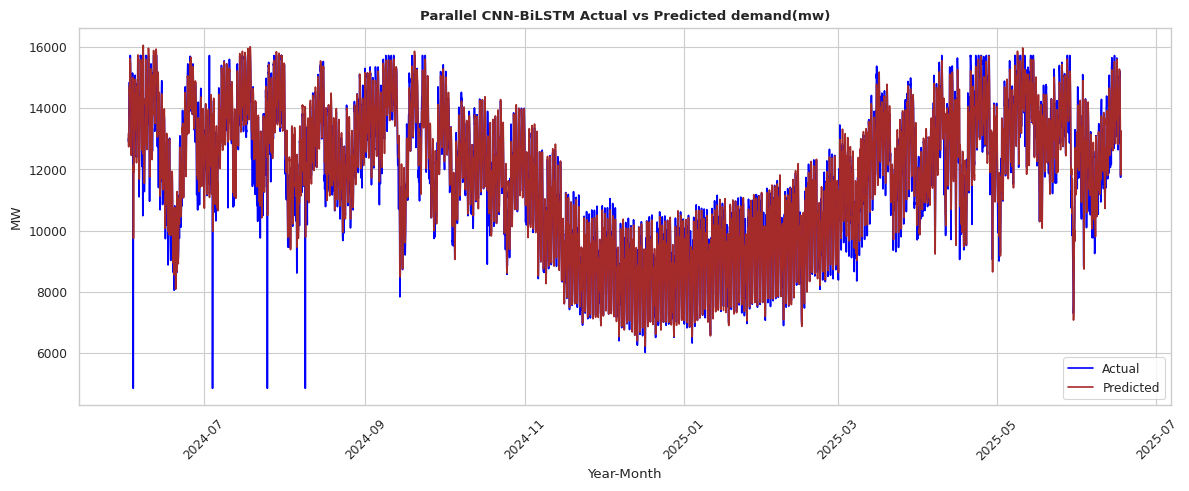

In [104]:

time_index = y.iloc[train_size + val_size + w:].index

plt.figure(figsize=(12,5))
plt.plot(time_index, y_true_inv, color='blue', label="Actual")
plt.plot(time_index, y_pred_inv, color='brown', label="Predicted")

plt.title("Parallel CNN-BiLSTM Actual vs Predicted demand(mw)")
plt.xlabel("Year-Month")
plt.ylabel("MW")

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("plot.png", dpi=300, bbox_inches='tight')
from google.colab import files

files.download("plot.png")
plt.show()
plt.close()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

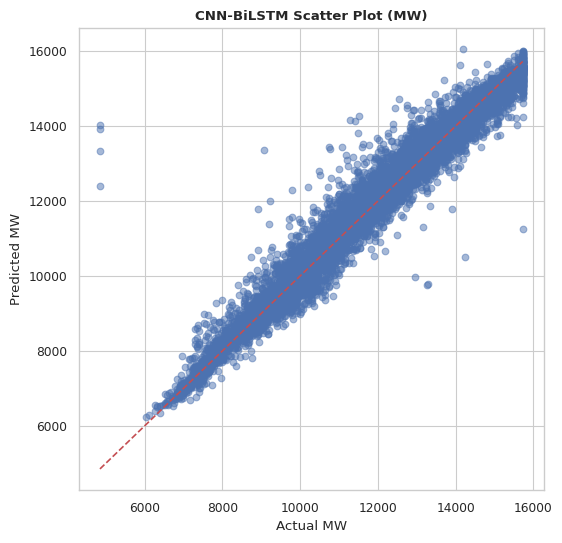

In [105]:
plt.figure(figsize=(6,6))
plt.scatter(y_true_inv, y_pred_inv, alpha=0.5)

plt.plot([y_true_inv.min(), y_true_inv.max()],
         [y_true_inv.min(), y_true_inv.max()],
         'r--')

plt.title("CNN-BiLSTM Scatter Plot (MW)")
plt.xlabel("Actual MW")
plt.ylabel("Predicted MW")

plt.savefig("plot.png", dpi=300, bbox_inches='tight')
from google.colab import files

files.download("plot.png")
plt.show()
plt.close()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

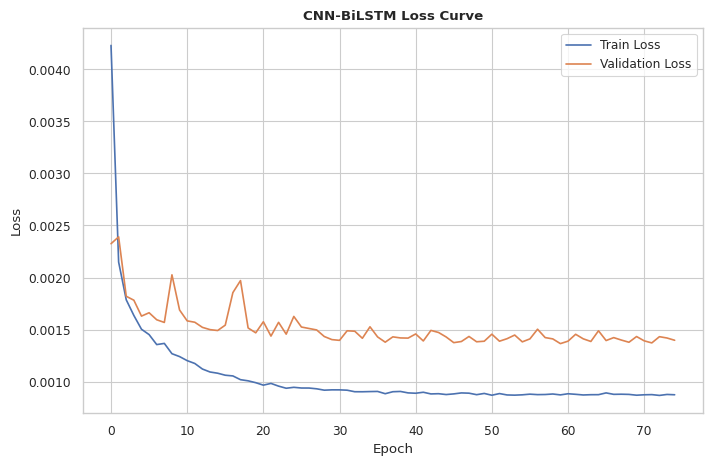

In [106]:
plt.figure(figsize=(8,5))

plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Validation Loss")

plt.title("CNN-BiLSTM Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.savefig("plot.png", dpi=300, bbox_inches='tight')
from google.colab import files

files.download("plot.png")
plt.show()
plt.close()

#CNN-GRU

In [107]:
import torch
import torch.nn as nn

class CNN_GRU(nn.Module):
    def __init__(self, input_features):
        super().__init__()

        # CNN branch
        self.conv1 = nn.Conv1d(input_features, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(64, 32, kernel_size=3, padding=1)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

        # GRU (instead of LSTM)
        self.gru = nn.GRU(
            input_size=32,
            hidden_size=32,
            batch_first=True
        )

        self.dropout_gru = nn.Dropout(0.25)

        # BatchNorm (GRU output size = 32)
        self.bn = nn.BatchNorm1d(32)

        # Fully connected layer
        self.fc = nn.Sequential(
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(32, 1)
        )

    def forward(self, x):

        # x: (batch, time, features)

        # CNN expects (batch, features, time)
        x = x.permute(0, 2, 1)

        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))

        x = self.dropout(x)

        # back to (batch, time, features)
        x = x.permute(0, 2, 1)

        # GRU
        out, _ = self.gru(x)

        # last timestep
        out = out[:, -1, :]

        out = self.dropout_gru(out)

        out = self.bn(out)

        out = self.fc(out)

        return out

In [108]:
model = CNN_GRU(input_features=x_train_w.shape[2])
print(model)

CNN_GRU(
  (conv1): Conv1d(15, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv2): Conv1d(64, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (gru): GRU(32, 32, batch_first=True)
  (dropout_gru): Dropout(p=0.25, inplace=False)
  (bn): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [109]:
criterion = nn.HuberLoss(delta=1.0)

In [110]:
import torch.optim as optim

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.0003,
    weight_decay=1e-4
)

In [111]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

In [112]:
epochs = 100

best_val = float("inf")
patience = 15
counter = 0

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for xb, yb in train_loader:

        optimizer.zero_grad()

        out = model(xb)
        loss = criterion(out, yb)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            out = model(xb)
            loss = criterion(out, yb)
            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    scheduler.step(val_loss)

    if val_loss < best_val:
        best_val = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_cnn_gru.pt")
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping")
        break

    if (epoch + 1) % 5 == 0:
        print(f"{epoch+1}/100 | Train:{train_loss:.6f} | Val:{val_loss:.6f}")

5/100 | Train:0.002271 | Val:0.002260
10/100 | Train:0.001873 | Val:0.001792
15/100 | Train:0.001708 | Val:0.001910
20/100 | Train:0.001620 | Val:0.001569
25/100 | Train:0.001604 | Val:0.001678
30/100 | Train:0.001576 | Val:0.001569
35/100 | Train:0.001579 | Val:0.001587
40/100 | Train:0.001565 | Val:0.001576
45/100 | Train:0.001566 | Val:0.001580
50/100 | Train:0.001556 | Val:0.001550
55/100 | Train:0.001552 | Val:0.001528
60/100 | Train:0.001550 | Val:0.001542
65/100 | Train:0.001557 | Val:0.001534
70/100 | Train:0.001538 | Val:0.001647
Early stopping


In [113]:
model.load_state_dict(torch.load("best_cnn_gru.pt"))
model.eval()

CNN_GRU(
  (conv1): Conv1d(15, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv2): Conv1d(64, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (gru): GRU(32, 32, batch_first=True)
  (dropout_gru): Dropout(p=0.25, inplace=False)
  (bn): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [114]:
pred = []

with torch.no_grad():
    for xb, _ in test_loader:
        pred.append(model(xb).cpu().numpy())

y_pred = np.concatenate(pred).reshape(-1)
y_true = y_test_w.reshape(-1)

In [115]:
y_true_inv = sy.inverse_transform(y_true.reshape(-1,1)).reshape(-1)
y_pred_inv = sy.inverse_transform(y_pred.reshape(-1,1)).reshape(-1)

mse = mean_squared_error(y_true_inv, y_pred_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_inv, y_pred_inv)
r2 = r2_score(y_true_inv, y_pred_inv)

mape = np.mean(np.abs((y_true_inv - y_pred_inv)/(y_true_inv+1e-8))) * 100

print("PERFORMANCE")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("MAPE:", mape)
print("R2  :", r2)

PERFORMANCE
MSE : 238829.0159638691
RMSE: 488.7013566216786
MAE : 328.0035643134108
MAPE: 2.89559956479317
R2  : 0.950771631613761


In [ ]:
import torch
import torch.nn as nn

class BiLSTMModel(nn.Module):
    def __init__(self, input_features):
        super().__init__()

        self.bilstm = nn.LSTM(
            input_size=input_features,
            hidden_size=32,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.2)

        self.fc = nn.Sequential(
            nn.Linear(64, 32),   # 32×2 = 64
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):

        out, _ = self.bilstm(x)

        out = out[:, -1, :]      # last timestep

        out = self.dropout(out)

        out = self.fc(out)

        return out


model = BiLSTMModel(x_train_w.shape[2])

print(model)

In [ ]:
import torch.optim as optim

criterion = nn.HuberLoss(delta=1.0)

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.0003,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

In [ ]:
import time
import numpy as np

epochs = 100

train_loss_list = []
val_loss_list = []

best_val = np.inf
patience = 15
counter = 0

start_time = time.time()

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for xb, yb in train_loader:

        optimizer.zero_grad()

        out = model(xb)

        loss = criterion(out, yb)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        train_loss += loss.item()

    model.eval()

    val_loss = 0

    with torch.no_grad():

        for xb, yb in val_loader:

            out = model(xb)

            loss = criterion(out, yb)

            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    scheduler.step(val_loss)

    if val_loss < best_val:

        best_val = val_loss
        counter = 0

        torch.save(
            model.state_dict(),
            "best_bilstm.pt"
        )

    else:
        counter += 1

    if counter >= patience:
        print("Early stopping")
        break

    if (epoch + 1) % 5 == 0:

        print(
            f"{epoch+1}/100 | Train:{train_loss:.6f} | Val:{val_loss:.6f}"
        )

print(
    "\nTOTAL TIME:",
    time.time() - start_time
)

model.load_state_dict(
    torch.load("best_bilstm.pt")
)

In [ ]:
model.eval()

pred = []

with torch.no_grad():

    for xb, _ in test_loader:

        pred.append(
            model(xb).cpu().numpy()
        )

y_pred = np.concatenate(pred).reshape(-1)

y_true = y_test_w.reshape(-1)

In [ ]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

y_true_inv = sy.inverse_transform(
    y_true.reshape(-1,1)
).reshape(-1)

y_pred_inv = sy.inverse_transform(
    y_pred.reshape(-1,1)
).reshape(-1)

mse = mean_squared_error(
    y_true_inv,
    y_pred_inv
)

rmse = np.sqrt(mse)

mae = mean_absolute_error(
    y_true_inv,
    y_pred_inv
)

r2 = r2_score(
    y_true_inv,
    y_pred_inv
)

mape = np.mean(
    np.abs(
        (y_true_inv - y_pred_inv)
        /(y_true_inv + 1e-8)
    )
) * 100

print("BiLSTM PERFORMANCE")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("MAPE:", mape)
print("R2  :", r2)

In [128]:
# Convert 3D → 2D

X_train_ml = x_train_w.reshape(
    x_train_w.shape[0],
    x_train_w.shape[1] * x_train_w.shape[2]
)

X_test_ml = x_test_w.reshape(
    x_test_w.shape[0],
    x_test_w.shape[1] * x_test_w.shape[2]
)

y_train_ml = y_train_w.reshape(-1)
y_test_ml = y_test_w.reshape(-1)

print(X_train_ml.shape)
print(X_test_ml.shape)

(44444, 360)
(9506, 360)


In [129]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_ml,
    y_train_ml
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [130]:
y_pred_xgb = xgb_model.predict(
    X_test_ml
)

In [131]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

y_true_inv = sy.inverse_transform(
    y_test_ml.reshape(-1,1)
).reshape(-1)

y_pred_inv = sy.inverse_transform(
    y_pred_xgb.reshape(-1,1)
).reshape(-1)

mse = mean_squared_error(
    y_true_inv,
    y_pred_inv
)

rmse = np.sqrt(mse)

mae = mean_absolute_error(
    y_true_inv,
    y_pred_inv
)

r2 = r2_score(
    y_true_inv,
    y_pred_inv
)

mape = np.mean(
    np.abs(
        (y_true_inv-y_pred_inv)/
        (y_true_inv+1e-8)
    )
)*100

print("XGBOOST PERFORMANCE")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("MAPE:", mape)
print("R2  :", r2)

XGBOOST PERFORMANCE
MSE : 732102.339717197
RMSE: 855.6297912749397
MAE : 635.7009994448409
MAPE: 5.183668896361334
R2  : 0.849096209978615


In [132]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_ml,
    y_train_ml
)

In [ ]:
y_pred_rf = rf_model.predict(
    X_test_ml
)

In [ ]:
y_true_inv = sy.inverse_transform(
    y_test_ml.reshape(-1,1)
).reshape(-1)

y_pred_inv = sy.inverse_transform(
    y_pred_rf.reshape(-1,1)
).reshape(-1)

mse = mean_squared_error(
    y_true_inv,
    y_pred_inv
)

rmse = np.sqrt(mse)

mae = mean_absolute_error(
    y_true_inv,
    y_pred_inv
)

r2 = r2_score(
    y_true_inv,
    y_pred_inv
)

mape = np.mean(
    np.abs(
        (y_true_inv-y_pred_inv)/
        (y_true_inv+1e-8)
    )
)*100

print("RANDOM FOREST PERFORMANCE")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("MAPE:", mape)
print("R2  :", r2)